In [223]:
# Data processing
# ==============================================================================
import numpy as np
import pandas as pd
import polars
from skforecast.datasets import fetch_dataset
import sys

# Plots
# ==============================================================================
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
import plotly.graph_objects as go
import plotly.io as pio
import plotly.offline as poff
pio.templates.default = "seaborn"
poff.init_notebook_mode(connected=True)

pd.set_option('display.float_format', '{:.6f}'.format)

Load dataframe with all model predictions

In [224]:
df_pred = pd.read_parquet('C:/Users/J.Heuvelmans/OneDrive - Brain Research Center/Documenten/EAISI/2024Applications/Group4B/Data/processed/df_pred20241211.parquet', engine='pyarrow')
df_holt = pd.read_parquet('C:/Users/J.Heuvelmans/OneDrive - Brain Research Center/Documenten/EAISI/2024Applications/Group4B/Data/processed/all_predictions.parquet', engine='pyarrow')
# df_test = pd.read_parquet('C:/Users/J.Heuvelmans/OneDrive - Brain Research Center/Documenten/EAISI/2024Applications/Group4B/Data/processed/df_test_with_forecasts_seperate_20241122.parquet', engine='pyarrow')
# df_val = pd.read_parquet('C:/Users/J.Heuvelmans/OneDrive - Brain Research Center/Documenten/EAISI/2024Supermarket/Data/processed/df_val_with_forecasts_20241120.parquet', engine='pyarrow')

In [225]:
df_pred

,store_nbr,item_nbr,unit_sales,week_number_cum,date,unique_id,y_naive,y_mean,store_cluster,item_class,perishable,store_type,item_family,y_xgb
0,10,1003679,82.000000,216,2017-02-13,0,22.833334,17.936508,15,1028,0,C,GROCERY I,22.812817
1,10,1003679,18.547619,217,2017-02-20,0,25.000000,20.222223,15,1028,0,C,GROCERY I,26.487423
2,10,1003679,14.000000,218,2017-02-27,0,82.000000,43.277778,15,1028,0,C,GROCERY I,43.555660
3,10,1003679,27.000000,219,2017-03-06,0,18.547619,41.849206,15,1028,0,C,GROCERY I,26.284838
4,10,1003679,24.000000,220,2017-03-13,0,14.000000,38.182540,15,1028,0,C,GROCERY I,23.429998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395871,9,996600,21.633333,237,2017-07-10,15225,20.000000,32.428571,6,1042,0,B,GROCERY I,27.800419
395872,9,996600,14.600000,238,2017-07-17,15225,12.547619,23.277777,6,1042,0,B,GROCERY I,23.642902
395873,9,996600,16.133333,239,2017-07-24,15225,21.633333,18.060317,6,1042,0,B,GROCERY I,23.678957
395874,9,996600,19.666668,240,2017-07-31,15225,14.600000,16.260317,6,1042,0,B,GROCERY I,21.954250


In [226]:
df_holt.loc[df_holt['y_pred'] < 0, 'y_pred'] = 0
df_holt


,store_nbr,item_nbr,date,y_true,y_pred
0,1,105857,2017-02-13,20.000000,16.204721
1,1,105857,2017-02-20,16.290476,18.479295
2,1,105857,2017-02-27,16.000000,12.630132
3,1,105857,2017-03-06,25.428572,25.689950
4,1,105857,2017-03-13,24.666668,33.569429
...,...,...,...,...,...
395871,54,1324670,2017-07-10,24.000000,23.712726
395872,54,1324670,2017-07-17,33.000000,19.151827
395873,54,1324670,2017-07-24,22.142857,32.814722
395874,54,1324670,2017-07-31,22.000000,24.651683


In [227]:
df_holt = df_holt.sort_values(by=['store_nbr', 'item_nbr', 'date']).reset_index(drop=True)
df_pred = df_pred.sort_values(by=['store_nbr', 'item_nbr', 'date']).reset_index(drop=True)

Below put in values for holt-winters predictions:

In [228]:
df_pred['y_holt'] = df_holt['y_pred']

In [229]:
df = df_pred
df.head()

,store_nbr,item_nbr,unit_sales,week_number_cum,date,unique_id,y_naive,y_mean,store_cluster,item_class,perishable,store_type,item_family,y_xgb,y_holt
0,1,105857,20.000000,216,2017-02-13,2457,23.333334,21.706349,13,1092,0,D,GROCERY I,23.195902,16.204721
1,1,105857,16.290476,217,2017-02-20,2457,21.000000,19.873016,13,1092,0,D,GROCERY I,23.700409,18.479295
2,1,105857,16.000000,218,2017-02-27,2457,20.000000,21.444445,13,1092,0,D,GROCERY I,22.710569,12.630132
3,1,105857,25.428572,219,2017-03-06,2457,16.290476,19.096825,13,1092,0,D,GROCERY I,21.835590,25.689950
4,1,105857,24.666668,220,2017-03-13,2457,16.000000,17.430159,13,1092,0,D,GROCERY I,19.162992,33.569429


In [230]:
df

,store_nbr,item_nbr,unit_sales,week_number_cum,date,unique_id,y_naive,y_mean,store_cluster,item_class,perishable,store_type,item_family,y_xgb,y_holt
0,1,105857,20.000000,216,2017-02-13,2457,23.333334,21.706349,13,1092,0,D,GROCERY I,23.195902,16.204721
1,1,105857,16.290476,217,2017-02-20,2457,21.000000,19.873016,13,1092,0,D,GROCERY I,23.700409,18.479295
2,1,105857,16.000000,218,2017-02-27,2457,20.000000,21.444445,13,1092,0,D,GROCERY I,22.710569,12.630132
3,1,105857,25.428572,219,2017-03-06,2457,16.290476,19.096825,13,1092,0,D,GROCERY I,21.835590,25.689950
4,1,105857,24.666668,220,2017-03-13,2457,16.000000,17.430159,13,1092,0,D,GROCERY I,19.162992,33.569429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395871,54,1324670,24.000000,237,2017-07-10,12925,42.833332,32.023809,3,1094,0,C,GROCERY I,30.969574,23.712726
395872,54,1324670,33.000000,238,2017-07-17,12925,23.000000,29.499999,3,1094,0,C,GROCERY I,27.352617,19.151827
395873,54,1324670,22.142857,239,2017-07-24,12925,24.000000,29.944444,3,1094,0,C,GROCERY I,23.680332,32.814722
395874,54,1324670,22.000000,240,2017-07-31,12925,33.000000,26.666667,3,1094,0,C,GROCERY I,26.407011,24.651683


Define functions for 
- calculating MAPE, 
- calculating bias and accuracy per item, 
- create dataframe with metrics (including costs),
- create dataframe with metrics per group (for example per store_type, or item_family),
- calculate summarized data (sum or mean)

In [231]:
def calculate_mape(actual, predicted):
    actual = np.array(actual)
    predicted = np.array(predicted)
    
    # Filter out zero actual values
    mask = actual != 0
    actual = actual[mask]
    predicted = predicted[mask]
    
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return mape

def calculate_bias_acc(df, prediction, actual):
    """
    Calculate bias, accuracy, and adjusted bias for predictions.
    
    Parameters:
        df (pd.DataFrame): The DataFrame containing the prediction and actual data.
        prediction (str): Column name for the predictions.
        actual (str): Column name for the actual values.

    Returns:
        pd.DataFrame: The DataFrame with new columns for bias, accuracy, and adjusted bias.
    """
    # Calculate bias
    df[f'bias_{prediction}'] = df[prediction] - df[actual]
    
    # Calculate accuracy
    df[f'acc_{prediction}'] = np.where(
        (df[actual] == 0) & (df[prediction] != 0),
        np.nan,
        (1 - np.abs(df[f'bias_{prediction}']) / df[actual]) * 100
    )
    
    # Calculate adjusted bias
    df[f'adj_bias_{prediction}'] = (df[f'bias_{prediction}'] * 2 / 3).where(
        df[f'bias_{prediction}'] >= 0, 
        df[f'bias_{prediction}'] * -1 / 3
    )
    
    return df

def calculate_metrics(df):
    # Calculate mean accuracies
    accuracy_xgb = np.mean(df['acc_y_xgb'])
    accuracy_naive = np.mean(df['acc_y_naive'])
    accuracy_mean = np.mean(df['acc_y_mean'])
    accuracy_holt = np.mean(df['acc_y_holt'])
        
    # Calculate bias and positive/negative bias for XGB and Naive models
    bias_xgb = np.mean(df['bias_y_xgb'])
    positive_bias_xgb = np.mean(df['bias_y_xgb'][df['bias_y_xgb'] > 0])
    negative_bias_xgb = np.mean(df['bias_y_xgb'][df['bias_y_xgb'] < 0])
    
    bias_naive = np.mean(df['bias_y_naive'])
    positive_bias_naive = np.mean(df['bias_y_naive'][df['bias_y_naive'] > 0])
    negative_bias_naive = np.mean(df['bias_y_naive'][df['bias_y_naive'] < 0])

    bias_mean = np.mean(df['bias_y_mean'])
    positive_bias_mean = np.mean(df['bias_y_mean'][df['bias_y_mean'] > 0])
    negative_bias_mean = np.mean(df['bias_y_mean'][df['bias_y_mean'] < 0])

    bias_holt = np.mean(df['bias_y_holt'])
    positive_bias_holt = np.mean(df['bias_y_holt'][df['bias_y_holt'] > 0])
    negative_bias_holt = np.mean(df['bias_y_holt'][df['bias_y_holt'] < 0])    

    # Calculate sum of adjusted bias
    adj_bias_xgb = np.sum(df['adj_bias_y_xgb'])
    adj_bias_naive = np.sum(df['adj_bias_y_naive'])
    adj_bias_mean = np.sum(df['adj_bias_y_mean'])
    adj_bias_holt = np.sum(df['adj_bias_y_holt'])
    diff_xgb_naive = adj_bias_naive - adj_bias_xgb
    diff_mean_naive = adj_bias_naive - adj_bias_mean
    diff_holt_naive = adj_bias_naive - adj_bias_holt

    # Calculate MAPE
    mape_xgb = calculate_mape(df['unit_sales'], df['y_xgb'])
    mape_naive = calculate_mape(df['unit_sales'], df['y_naive'])
    mape_mean = calculate_mape(df['unit_sales'], df['y_mean'])
    mape_holt = calculate_mape(df['unit_sales'], df['y_holt'])
       
    # Store results in a dictionary
    results = {
        'Metric': [
            'Mean Accuracy XGB', 'Mean Accuracy Naive',
            'Mean Accuracy Mean', 'Mean Accuracy Holt',
            'MAPE XGB', 'MAPE Naive', 'MAPE Mean', 'MAPE Holt',
            'Bias XGB', 'Positive Bias XGB', 'Negative Bias XGB', 
            'Bias Naive', 'Positive Bias Naive', 'Negative Bias Naive',
            'Bias Mean', 'Positive Bias Mean', 'Negative Bias Mean',
            'Bias Holt', 'Positive Bias Holt', 'Negative Bias Holt',
            'Money XGB', 'Money Naive', 'Money Mean', 'Money Holt',
            'Difference Naive - XGB', 'Difference Naive - Mean', 'Difference Naive - Holt'
        ],
        'Value': [
            accuracy_xgb, accuracy_naive, 
            accuracy_mean, accuracy_holt,
            mape_xgb, mape_naive, mape_mean, mape_holt,
            bias_xgb, positive_bias_xgb, negative_bias_xgb,
            bias_naive, positive_bias_naive, negative_bias_naive,
            bias_mean, positive_bias_mean, negative_bias_mean,
            bias_holt, positive_bias_holt, negative_bias_holt,
            adj_bias_xgb, adj_bias_naive, adj_bias_mean, adj_bias_holt,
            diff_xgb_naive, diff_mean_naive, diff_holt_naive
        ]
    }
    
    # Convert results dictionary to a DataFrame
    results_df = pd.DataFrame(results)
    
    return results_df

def calculate_costs_of_bias(df):
    cost_overprediction_naive = np.sum(df['bias_y_naive'][df['bias_y_naive'] > 0]) * 2/3
    cost_underprediction_naive = np.sum(df['bias_y_naive'][df['bias_y_naive'] < 0]) * -1/3

    cost_overprediction_xgb = cost_overprediction_naive - (np.sum(df['bias_y_xgb'][df['bias_y_xgb'] > 0]) * 2/3)
    cost_underprediction_xgb = cost_underprediction_naive - (np.sum(df['bias_y_xgb'][df['bias_y_xgb'] < 0]) * -1/3)

    cost_overprediction_mean = cost_overprediction_naive - (np.sum(df['bias_y_mean'][df['bias_y_mean'] > 0]) * 2/3)
    cost_underprediction_mean = cost_underprediction_naive - (np.sum(df['bias_y_mean'][df['bias_y_mean'] < 0]) * -1/3)

    cost_overprediction_holt = cost_overprediction_naive - (np.sum(df['bias_y_holt'][df['bias_y_holt'] > 0]) * 2/3)
    cost_underprediction_holt = cost_underprediction_naive - (np.sum(df['bias_y_holt'][df['bias_y_holt'] < 0]) * -1/3)

    print(f"Cost Overprediction NAIVE - XGB: {cost_overprediction_xgb}")
    print(f"Cost Underprediction NAIVE - XGB: {cost_underprediction_xgb}")
    print(f"Cost Overprediction NAIVE - moving average: {cost_overprediction_mean}")
    print(f"Cost Underprediction NAIVE - moving average: {cost_underprediction_mean}")
    print(f"Cost Overprediction NAIVE - holt winters: {cost_overprediction_holt}")
    print(f"Cost Underprediction NAIVE - holt winters: {cost_underprediction_holt}")    

def calculate_metrics_grouped(df, column):
    store_stats = []
    
    # Iterate over each group's data
    for store, group in df.groupby(column):
        # # Skip calculation if the group value is 0 or missing (NaN)
        # if store == 0 or pd.isna(store):
        #     continue
        
        # Calculate statistics for the current group using the existing function
        df_metrics = calculate_metrics(group)
        
        # Add the column value (e.g., store number) to each metric's result for reference
        df_metrics[column] = store
        
        # Append each group's result to the list
        store_stats.append(df_metrics)
    
    # Concatenate all group statistics into a single DataFrame
    store_means = pd.concat(store_stats).reset_index(drop=True)

    # Pivot the DataFrame to make column values into columns and Metric rows
    store_metrics_pivot = store_means.pivot(index='Metric', columns=column, values='Value')

    # Drop columns with all NA values
    store_metrics_pivot = store_metrics_pivot.dropna(axis=1, how='all')

    return store_metrics_pivot

def summarize_store_data(df, group_column, summary_columns, operation='sum'):
    if operation == 'sum':
        grouped_df = df.groupby(group_column)[summary_columns].sum().reset_index()
    elif operation == 'mean':
        grouped_df = df.groupby(group_column)[summary_columns].mean().reset_index()
    else:
        raise ValueError("Invalid operation. Choose 'sum' or 'mean'.")
    
    return grouped_df

Run function 'calculate_bias_acc' for every column containing the predictions of a model, listed in the list_pred

In [232]:
list_pred = ['y_xgb', 'y_mean', 'y_naive', 'y_holt']

# Apply the function for every prediction column in list_pred
for pred in list_pred:
    df = calculate_bias_acc(df, pred, 'unit_sales')

# Display the updated DataFrame
df.head()

,store_nbr,item_nbr,unit_sales,week_number_cum,date,unique_id,y_naive,y_mean,store_cluster,item_class,...,adj_bias_y_xgb,bias_y_mean,acc_y_mean,adj_bias_y_mean,bias_y_naive,acc_y_naive,adj_bias_y_naive,bias_y_holt,acc_y_holt,adj_bias_y_holt
0,1,105857,20.000000,216,2017-02-13,2457,23.333334,21.706349,13,1092,...,2.130601,1.706349,91.468253,1.137566,3.333334,83.333328,2.222223,-3.795279,81.023605,1.265093
1,1,105857,16.290476,217,2017-02-20,2457,21.000000,19.873016,13,1092,...,4.939955,3.582540,78.008376,2.388360,4.709524,71.090324,3.139683,2.188819,86.563812,1.459213
2,1,105857,16.000000,218,2017-02-27,2457,20.000000,21.444445,13,1092,...,4.473713,5.444445,65.972221,3.629630,4.000000,75.000000,2.666667,-3.369868,78.938325,1.123289
3,1,105857,25.428572,219,2017-03-06,2457,16.290476,19.096825,13,1092,...,1.197660,-6.331746,75.099874,2.110582,-9.138096,64.063667,3.046032,0.261379,98.972107,0.174252
4,1,105857,24.666668,220,2017-03-13,2457,16.000000,17.430159,13,1092,...,1.834558,-7.236509,70.662802,2.412170,-8.666668,64.864861,2.888889,8.902761,63.907729,5.935174


Calculate how much the model saves compared to naive:

In [233]:
calculate_costs_of_bias(df)

Cost Overprediction NAIVE - XGB: 523271.333333333
Cost Underprediction NAIVE - XGB: 279907.66666666674
Cost Overprediction NAIVE - moving average: 163797.10049811332
Cost Underprediction NAIVE - moving average: 84499.9955868707
Cost Overprediction NAIVE - holt winters: -266165.33001553593
Cost Underprediction NAIVE - holt winters: -2451.9285294730216


Calculate RMSE:

In [234]:
# Example columns: 'actual' and 'predicted'
def calculate_rmse(df, actual_col, predicted_col):
    mse = np.mean((df[actual_col] - df[predicted_col]) ** 2)  # Mean Squared Error
    rmse = np.sqrt(mse)  # Root Mean Squared Error
    return rmse

# Assuming the DataFrame has columns 'actual' and 'predicted'
rmse_naive = calculate_rmse(df_pred, 'unit_sales', 'y_naive')
print(f"RMSE naive: {rmse_naive}")
rmse_xgb = calculate_rmse(df_pred, 'unit_sales', 'y_xgb')
print(f"RMSE xgb: {rmse_xgb}")
rmse_mean = calculate_rmse(df_pred, 'unit_sales', 'y_mean')
print(f"RMSE mean: {rmse_mean}")
rmse_holt = calculate_rmse(df_pred, 'unit_sales', 'y_holt')
print(f"RMSE holt: {rmse_holt}")

RMSE naive: 118.4963150024414
RMSE xgb: 90.56849670410156
RMSE mean: 108.54616344593248
RMSE holt: 100.62618312301542


Overview of metrics:

In [235]:
df_metrics = calculate_metrics(df)
df_metrics

,Metric,Value
0,Mean Accuracy XGB,60.697037
1,Mean Accuracy Naive,58.390125
2,Mean Accuracy Mean,60.801950
3,Mean Accuracy Holt,53.883648
4,MAPE XGB,39.302960
5,MAPE Naive,41.609886
6,MAPE Mean,39.198050
7,MAPE Holt,46.116352
8,Bias XGB,0.324994
9,Positive Bias XGB,13.396878


For Holt-Winters: Looking for top 5 best and least performing store, item_class, item_nbr and store_item combinations

In [236]:
df['uniqueID'] = df['store_nbr'].astype(str) + "_" + df['item_nbr'].astype(str)

In [237]:
grouped_store_nbr = calculate_metrics_grouped(df, 'store_nbr')

# Choose a specific row (e.g., store_nbr = 3)
row = grouped_store_nbr.loc['Money Holt']

# Sort values in descending order for top 5 maximums
top_5_max = row.sort_values(ascending=False).head(1)

# Sort values in ascending order for top 5 minimums
top_5_min = row.sort_values(ascending=True).head(1)

# Print the results
print(f"Row: {row.name}")
print("\nTop 5 Least performing Values:")
for col, value in top_5_max.items():
    print(f"Column: {col}, Value: {value}")

print("\nTop 5 Best performing Values:")
for col, value in top_5_min.items():
    print(f"Column: {col}, Value: {value}")


grouped_item_class = calculate_metrics_grouped(df, 'item_class')

# Choose a specific row (e.g., store_nbr = 3)
row = grouped_item_class.loc['Money Holt']

# Sort values in descending order for top 5 maximums
top_5_max = row.sort_values(ascending=False).head(1)

# Sort values in ascending order for top 5 minimums
top_5_min = row.sort_values(ascending=True).head(1)

# Print the results
print(f"Row: {row.name}")
print("\nTop 5 Least performing Values:")
for col, value in top_5_max.items():
    print(f"Column: {col}, Value: {value}")

print("\nTop 5 Best performing Values:")
for col, value in top_5_min.items():
    print(f"Column: {col}, Value: {value}")


grouped_item_nbr = calculate_metrics_grouped(df, 'item_nbr')

# Choose a specific row (e.g., store_nbr = 3)
row = grouped_item_nbr.loc['Money Holt']

# Sort values in descending order for top 5 maximums
top_5_max = row.sort_values(ascending=False).head(1)

# Sort values in ascending order for top 5 minimums
top_5_min = row.sort_values(ascending=True).head(1)

# Print the results
print(f"Row: {row.name}")
print("\nTop 5 Least performing Values:")
for col, value in top_5_max.items():
    print(f"Column: {col}, Value: {value}")

print("\nTop 5 Best performing Values:")
for col, value in top_5_min.items():
    print(f"Column: {col}, Value: {value}")



grouped_uniqueID = calculate_metrics_grouped(df, 'uniqueID')

# Choose a specific row (e.g., store_nbr = 3)
row = grouped_uniqueID.loc['Money Holt']

# Sort values in descending order for top 5 maximums
top_5_max = row.sort_values(ascending=False).head(5)

# Sort values in ascending order for top 5 minimums
top_5_min = row.sort_values(ascending=True).head(5)

# Print the results
print(f"Row: {row.name}")
print("\nTop 5 Least performing Values:")
for col, value in top_5_max.items():
    print(f"Column: {col}, Value: {value}")

print("\nTop 5 Best performing Values:")
for col, value in top_5_min.items():
    print(f"Column: {col}, Value: {value}")

Row: Money Holt

Top 5 Least performing Values:
Column: 46, Value: 263223.5492285731

Top 5 Best performing Values:
Column: 35, Value: 38191.21751172154
Row: Money Holt

Top 5 Least performing Values:
Column: 1040, Value: 547242.2509314436

Top 5 Best performing Values:
Column: 1035, Value: 53.01511701146139
Row: Money Holt

Top 5 Least performing Values:
Column: 1157329, Value: 247548.8768079617

Top 5 Best performing Values:
Column: 1123722, Value: 41.10130148520386
Row: Money Holt

Top 5 Least performing Values:
Column: 46_1157329, Value: 33676.75498000329
Column: 32_1157329, Value: 33039.83875169659
Column: 41_1157329, Value: 28976.144408199434
Column: 39_1157329, Value: 25687.5952119601
Column: 39_1162382, Value: 21769.155070290988

Top 5 Best performing Values:
Column: 23_765518, Value: 20.394317155160948
Column: 40_211999, Value: 21.45770799986586
Column: 10_557810, Value: 22.75825380784623
Column: 41_1176559, Value: 23.380474717060846
Column: 40_122419, Value: 23.41271609017974

Show metrics grouped by column, for example store_type, item_family. All possibilities are shown in list_grouping

In [238]:
# Choose a specific row (e.g., store_nbr = 3)
row = df_metrics_grouped.loc['Money Holt']

# Sort values in descending order for top 5 maximums
top_5_max = row.sort_values(ascending=False).head(5)

# Sort values in ascending order for top 5 minimums
top_5_min = row.sort_values(ascending=True).head(5)

# Print the results
print(f"Row: {row.name}")
print("\nTop 5 Maximum Values:")
for col, value in top_5_max.items():
    print(f"Column: {col}, Value: {value}")

print("\nTop 5 Minimum Values:")
for col, value in top_5_min.items():
    print(f"Column: {col}, Value: {value}")

Row: Money Holt

Top 5 Maximum Values:
Column: 225, Value: 279819.2995148002
Column: 226, Value: 195559.5031727966
Column: 227, Value: 177738.12156356988
Column: 228, Value: 176047.4376377536
Column: 224, Value: 174636.51572717953

Top 5 Minimum Values:
Column: 240, Value: 142209.60098139948
Column: 237, Value: 146580.12008936325
Column: 234, Value: 147092.9851850576
Column: 236, Value: 147729.52340751165
Column: 238, Value: 150061.11452004174


In [239]:
list_grouping = ['store_type', 'store_cluster', 'store_nbr', 'perishable', 'item_family', 'item_class', 'week_number_cum']

# Initialize an empty dictionary
dict_df_metrics = {}

for i in list_grouping:
    # Calculate metrics for the current grouping
    df_metrics_grouped = calculate_metrics_grouped(df, i)
    dict_df_metrics[i] = df_metrics_grouped  # Add the resulting DataFrame to the dictionary with `i` as the key
    print(df_metrics_grouped)

store_type                           A             B             C  \
Metric                                                               
Bias Holt                     2.077095      0.064046      0.072408   
Bias Mean                     0.524570     -0.157171     -0.374445   
Bias Naive                    0.519682     -0.091403     -0.303463   
Bias XGB                     -0.782421     -0.951810      0.300686   
Difference Naive - Holt  -65357.698336  -5457.719270 -82867.160473   
Difference Naive - Mean  106937.070870  35295.330645  36235.924531   
Difference Naive - XGB   342540.625000 133711.906250 131567.000000   
MAPE Holt                    44.086691     46.907381     50.628004   
MAPE Mean                    37.661996     41.296518     41.853218   
MAPE Naive                   39.569765     44.760877     44.700277   
MAPE XGB                     34.380600     39.031586     47.022167   
Mean Accuracy Holt           55.913309     53.092619     49.371996   
Mean Accuracy Mean  

Show sum of sales, predictions, accuracy and bias - per group, listed in list_groups

In [240]:
for i in list_grouping:
    df_sum = summarize_store_data(df, group_column=i, 
                              summary_columns=['unit_sales', 'y_naive', 'y_xgb', 'y_mean', 'y_holt',  
                                               'acc_y_xgb', 'acc_y_naive', 'acc_y_mean', 'acc_y_holt', 
                                               'adj_bias_y_xgb', 'adj_bias_y_naive', 'adj_bias_y_mean', 'adj_bias_y_holt'],
                              operation='sum')
    print(df_sum)

  store_type     unit_sales        y_naive          y_xgb         y_mean  \
0          A 8624708.000000 8674999.000000 8548992.000000 8675471.865437   
1          B 2689161.750000 2685216.750000 2648081.500000 2682378.173536   
2          C 3959273.500000 3928344.500000 3989919.250000 3921109.967460   
3          D 7306502.500000 7364927.500000 7521310.500000 7382332.040317   

          y_holt      acc_y_xgb    acc_y_naive     acc_y_mean     acc_y_holt  \
0 8825712.798261 6306549.000000 5807828.500000 5991180.842669 5373716.341923   
1 2691925.907250 2611277.000000 2365891.500000 2514270.127433 2273956.865046   
2 3966653.227697 5335662.500000 5569511.500000 5856253.169904 4972500.560980   
3 7561087.986963 9543941.000000 9149723.000000 9476855.550740 8505934.394786   

   adj_bias_y_xgb  adj_bias_y_naive  adj_bias_y_mean  adj_bias_y_holt  
0  1108450.625000    1450991.000000   1344054.054130   1516348.823336  
1   422060.593750     555772.437500    520477.169355    561230.219270  
2 

Show mean of sales, predictions, accuracy and bias - per group, listed in list_groups


In [241]:
for i in list_grouping:
    df_mean = summarize_store_data(df, group_column=i, 
                              summary_columns=['unit_sales', 'y_naive', 'y_xgb', 'y_mean', 'y_holt',  
                                               'acc_y_xgb', 'acc_y_naive', 'acc_y_mean', 'acc_y_holt', 
                                               'adj_bias_y_xgb', 'adj_bias_y_naive', 'adj_bias_y_mean', 'adj_bias_y_holt'],
                              operation='mean')
    print(df_mean)

  store_type  unit_sales   y_naive     y_xgb    y_mean    y_holt  acc_y_xgb  \
0          A   89.124001 89.643692 88.341583 89.648575 91.201099  65.619400   
1          B   62.306805 62.215401 61.354992 62.149633 62.370850  60.968410   
2          C   38.846874 38.543411 39.147560 38.472429 38.919282  52.977833   
3          D   47.437428 47.816753 48.832069 47.929751 49.090324  62.617710   

   acc_y_naive  acc_y_mean  acc_y_holt  adj_bias_y_xgb  adj_bias_y_naive  \
0    60.430229   62.338004   55.913309       11.454249         14.993914   
1    55.239120   58.703482   53.092619        9.778975         12.877026   
2    55.299721   58.146782   49.371996        6.858386          8.149270   
3    60.031250   62.177564   55.807359        6.615642          7.884018   

   adj_bias_y_mean  adj_bias_y_holt  
0        13.888873        15.669293  
1        12.059249        13.003481  
2         7.793738         8.962332  
3         7.430652         8.630227  
    store_cluster  unit_sales    

Define functions to create visualisations:
- Histograms to show different in cost compared to naive, for every model. This histogram is sorted by biggest difference
- Linegraph to show sales for different models (possibility to group on a column)

In [242]:
def sorted_histogram(dict_df, group_names):
    """
    Plots sorted histograms for the first row (sorted) and unsorted histograms for others.
    The bars for each row are plotted next to each other.

    Parameters:
        dict_df (dict): A dictionary where keys are group names and values are DataFrames.
        group_names (list): A list of row names to plot.

    Returns:
        None
    """
    # Iterate over each DataFrame in the dictionary
    for key, df in dict_df.items():
        print(f"Processing group: {key}")
        
        # Create a new figure for each group
        plt.figure(figsize=(12, 8))
        
        # Get the number of elements in the first row to define x positions
        # (Assumes all rows have the same length, but you could adjust for mismatched lengths)
        num_elements = len(df.loc[group_names[0]])
        
        # Initialize the width of each bar and set the starting position for the bars
        bar_width = 0.2
        index = np.arange(num_elements)  # positions for the x-axis
        
        # Sort the first group (group_names[0]) and keep track of the sorted index
        sorted_index = None
        
        # Loop through each group name in the provided list
        for i, group_name in enumerate(group_names):
            # Ensure the row exists in the DataFrame
            if group_name not in df.index:
                raise ValueError(f"Row '{group_name}' not found in the DataFrame index of group '{key}'.")
            
            # Extract the specified row
            difference_row = df.loc[group_name]
            
            # Sort the first group (group_names[0]) only and record the sorted order
            if i == 0:
                difference_row = difference_row.sort_values(ascending=False)
                sorted_index = difference_row.index  # Save the sorted order for subsequent rows
            
            # For subsequent rows, reorder them to match the sorted order of the first row
            else:
                difference_row = difference_row[sorted_index]
            
            # Plot the histogram for each group_name, shifting bars by `i * bar_width`
            # This ensures the bars for different rows are placed next to each other
            plt.bar(index + i * bar_width, difference_row, width=bar_width, label=group_name)
        
        # Add title, labels, and grid
        plt.title(f'Saved money compared to naive, per: {key}', fontsize=14)
        plt.xlabel({key}, fontsize=12)
        plt.ylabel('Saved money', fontsize=12)
        
        # Adjust x-ticks to correspond to the center of the grouped bars
        plt.xticks(index + bar_width * (len(group_names) - 1) / 2, sorted_index.astype(str), rotation=90)
        
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.legend(title="Rows", fontsize=10)
        
        # Adjust layout and show the plot
        plt.tight_layout()
        plt.show()


In [243]:
def plot_sales_comparison(df, filter_column, filter_value):
    """
    Plots a comparison of predicted sales (y_xgb), actual sales (unit_sales), and naive predictions (y_naive)
    over weeks for a specified store (or any other column-based filter).

    Parameters:
    df_pred (pd.DataFrame): DataFrame containing the data.
    filter_column (str): The column name to filter by (e.g., 'store_nbr').
    filter_value (int or str): The value to filter the specified column by (e.g., a store number).
    """
    # Step 1: Filter data for the specified column and value
    grouped_df = df[df[filter_column] == filter_value]

    # Step 2: Group by 'week_number_cum' and compute the sum for each of the columns
    grouped_df = grouped_df.groupby('week_number_cum')[['y_xgb', 'unit_sales', 'y_naive', 'y_mean', 'y_holt']].sum().reset_index()

    # Step 3: Plot the results
    plt.figure(figsize=(12, 6))
    plt.plot(grouped_df['week_number_cum'], grouped_df['y_xgb'], marker='o', label='XGB prediction (y_xgb)', color='blue')
    plt.plot(grouped_df['week_number_cum'], grouped_df['unit_sales'], marker='o', label='Actual Sales (unit_sales)', color='black')
    plt.plot(grouped_df['week_number_cum'], grouped_df['y_naive'], marker='o', label='Naive prediction (y_naive)', color='red')
    plt.plot(grouped_df['week_number_cum'], grouped_df['y_mean'], marker='o', label='Average mean prediction (y_mean)', color='orange')
    plt.plot(grouped_df['week_number_cum'], grouped_df['y_holt'], marker='o', label='Holt Winters prediction (y_holt)', color='green')

    # Add titles and labels
    plt.title(f'Sum of Predicted sales vs Actual sales Over Weeks for {filter_column} = {filter_value}')
    plt.xlabel('Week Number Cumulative')
    plt.ylabel('Sales')
    plt.xticks(grouped_df['week_number_cum'])  # Set x-ticks to show all weeks
    plt.legend()
    plt.grid()

    # Show the plot
    plt.tight_layout()
    plt.show()


Line graph for total sales:

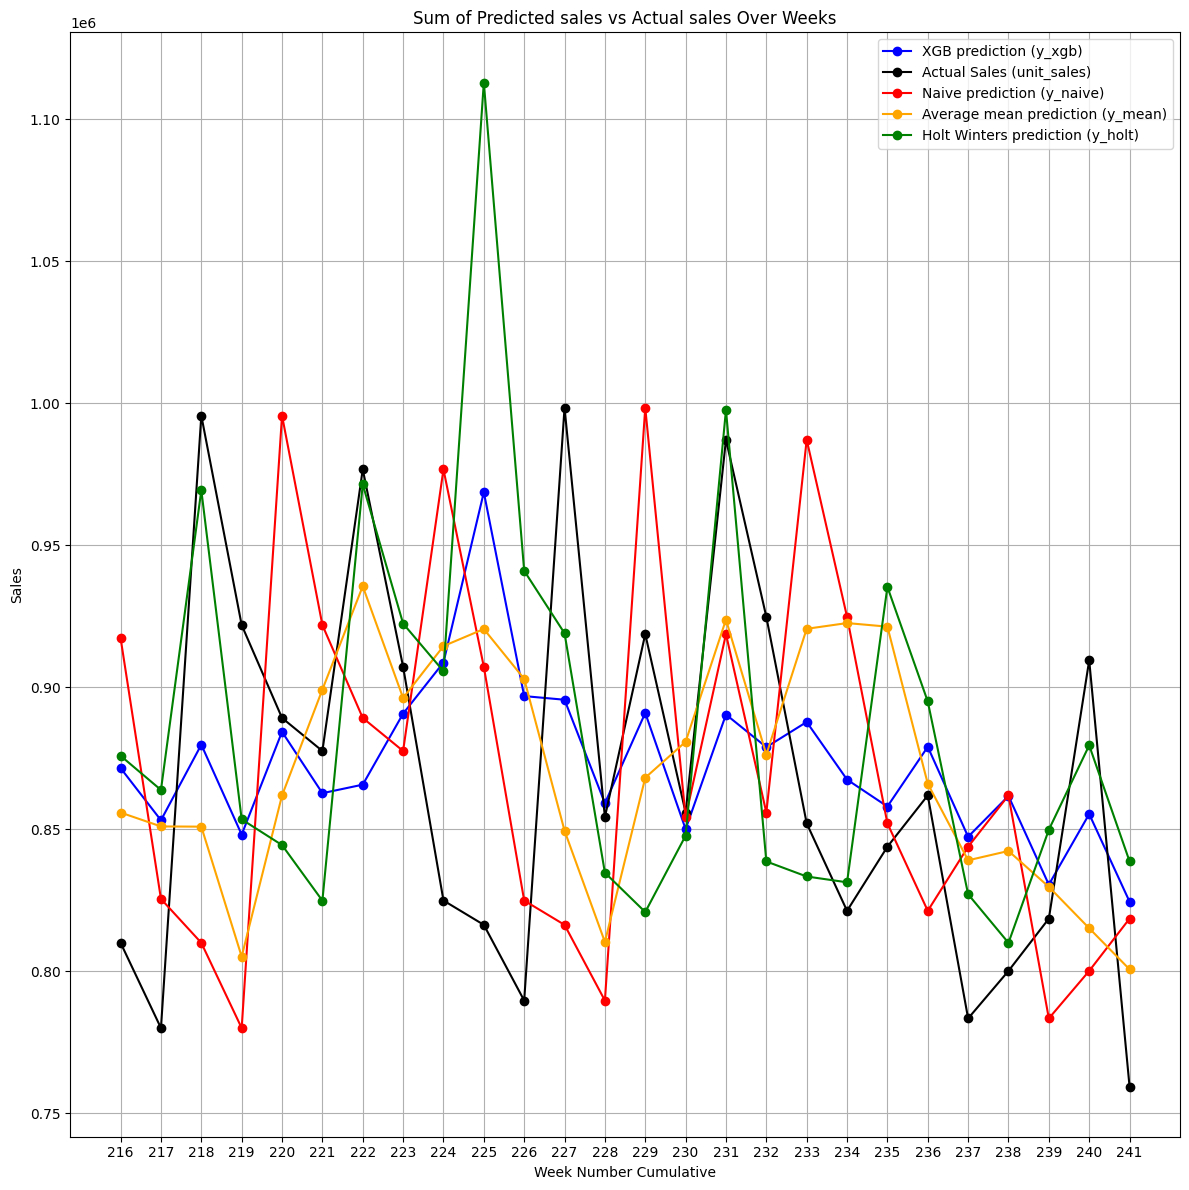

In [244]:
    grouped_df = df
    # Step 2: Group by 'week_number_cum' and compute the sum for each of the columns
    grouped_df = grouped_df.groupby('week_number_cum')[['y_xgb', 'unit_sales', 'y_naive', 'y_mean', 'y_holt']].sum().reset_index()

    # Step 3: Plot the results
    plt.figure(figsize=(12, 12))
    plt.plot(grouped_df['week_number_cum'], grouped_df['y_xgb'], marker='o', label='XGB prediction (y_xgb)', color='blue')
    plt.plot(grouped_df['week_number_cum'], grouped_df['unit_sales'], marker='o', label='Actual Sales (unit_sales)', color='black')
    plt.plot(grouped_df['week_number_cum'], grouped_df['y_naive'], marker='o', label='Naive prediction (y_naive)', color='red')
    plt.plot(grouped_df['week_number_cum'], grouped_df['y_mean'], marker='o', label='Average mean prediction (y_mean)', color='orange')
    plt.plot(grouped_df['week_number_cum'], grouped_df['y_holt'], marker='o', label='Holt Winters prediction (y_holt)', color='green')

    # Add titles and labels
    plt.title(f'Sum of Predicted sales vs Actual sales Over Weeks')
    plt.xlabel('Week Number Cumulative')
    plt.ylabel('Sales')
    plt.xticks(grouped_df['week_number_cum'])  # Set x-ticks to show all weeks
    plt.legend()
    plt.grid()

    # Show the plot
    plt.tight_layout()
    plt.show()

Line graph for total sales, grouped by a column, for example item_family, store_type etc...

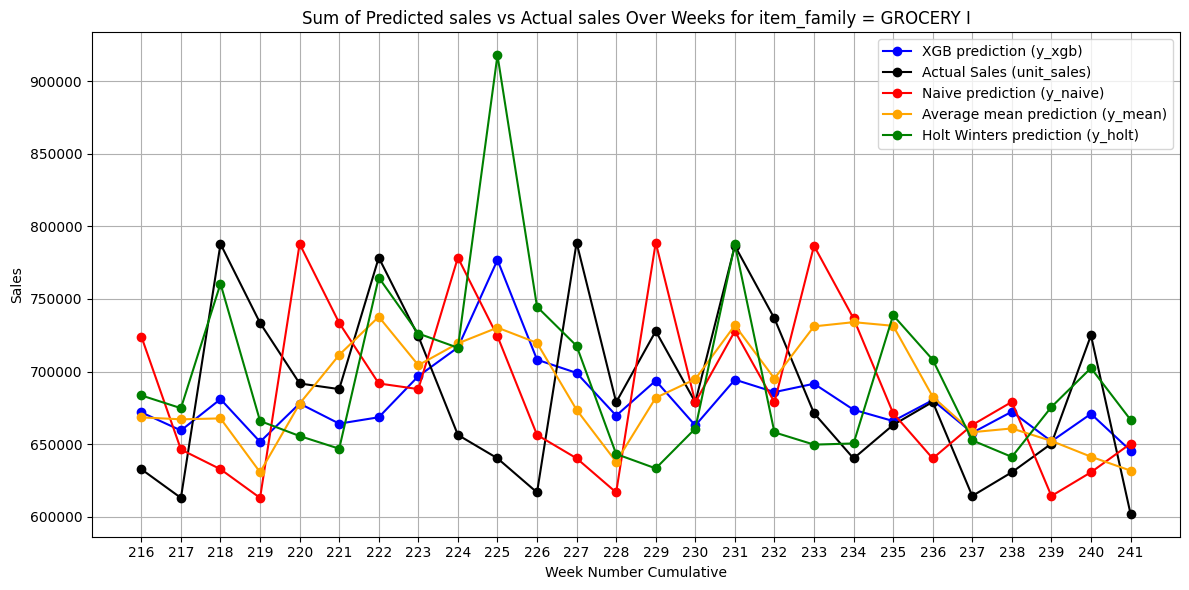

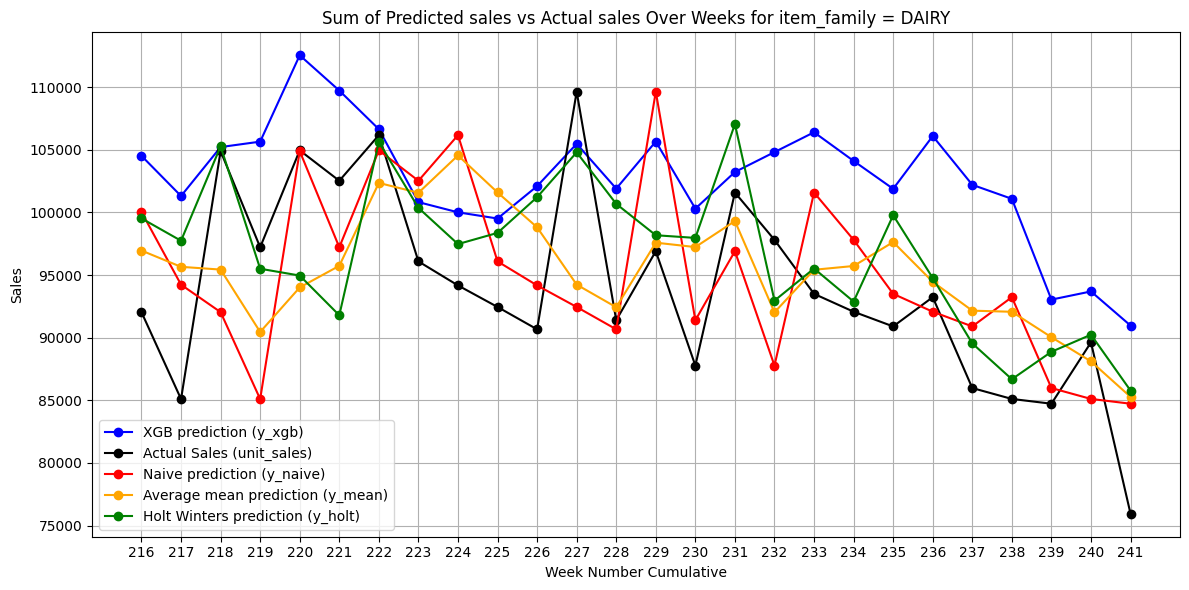

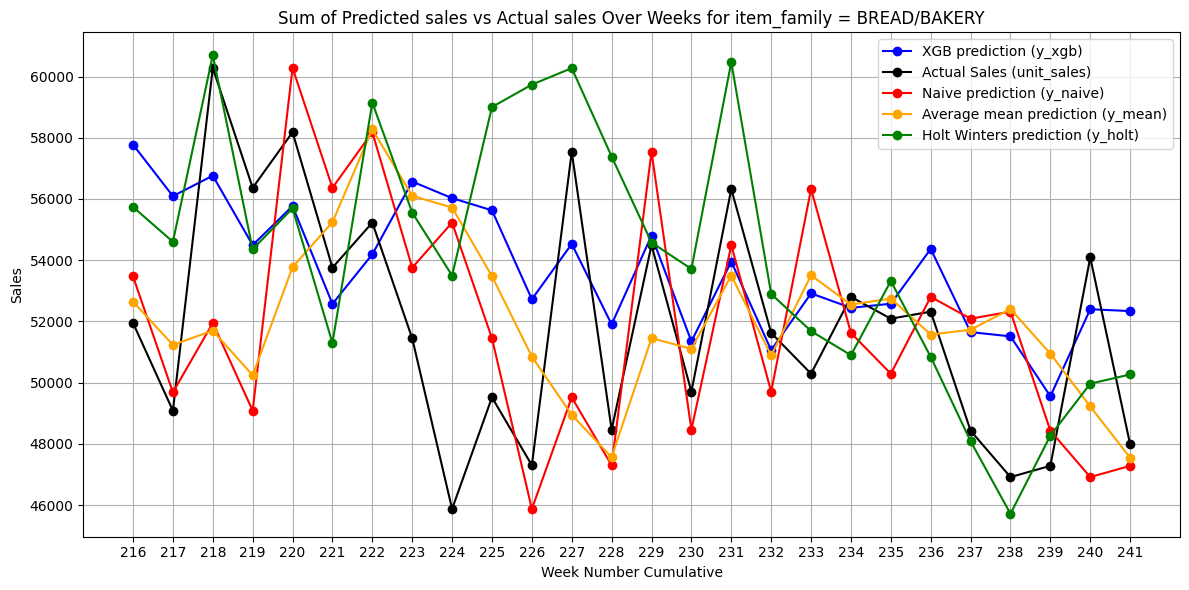

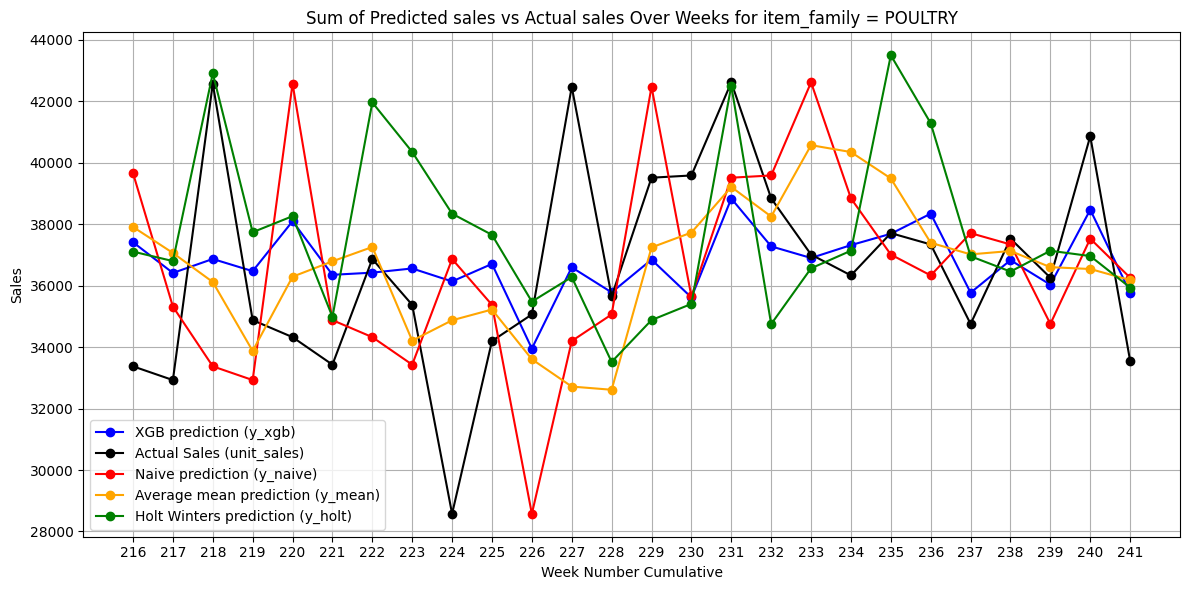

In [245]:
# Choose from list_grouping a column, get unique values, and create line graphs with total actual sales, predicted sales and naive prediction

column = 'item_family'
# Get unique values in the current column
unique_values = df[column].unique()
    
# Loop through each unique value in the column
for value in unique_values:
    # Call the plot_sales_comparison function
    plot_sales_comparison(df, filter_column=column, filter_value=value)


Plot the difference between naive and a model in histograms per group

Processing group: store_type


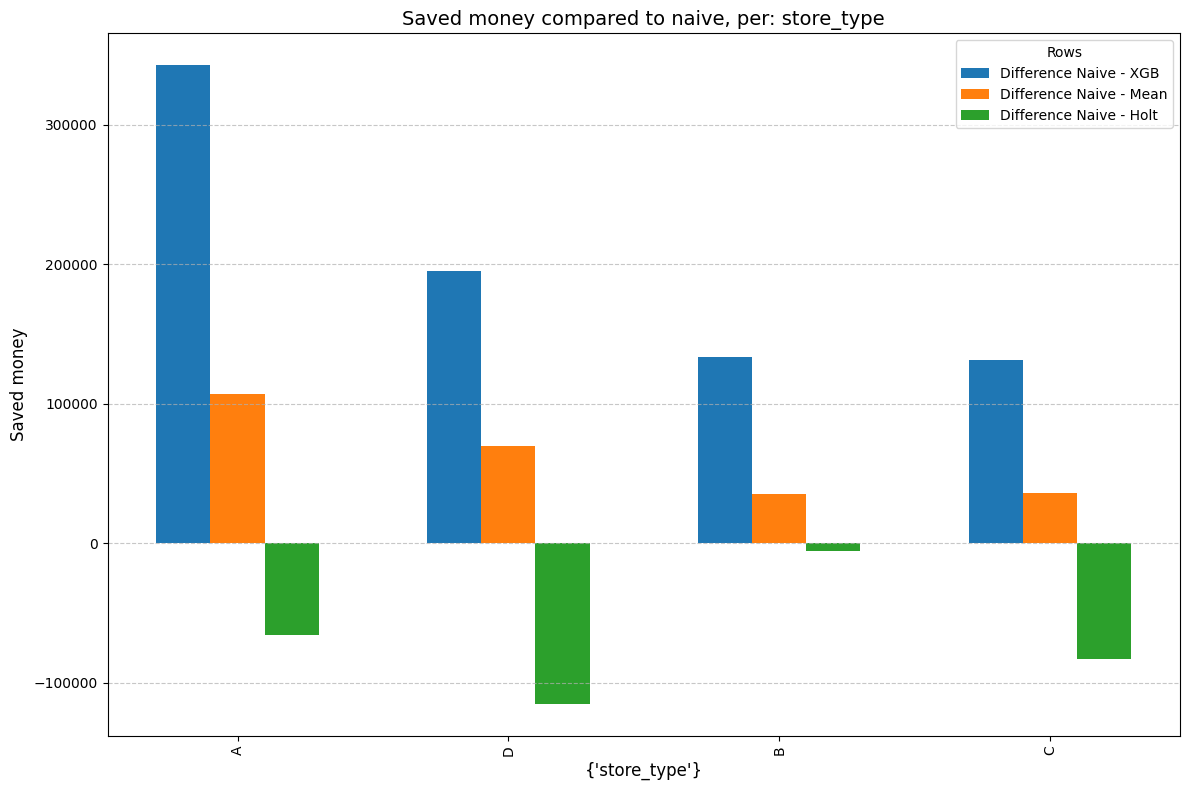

Processing group: store_cluster


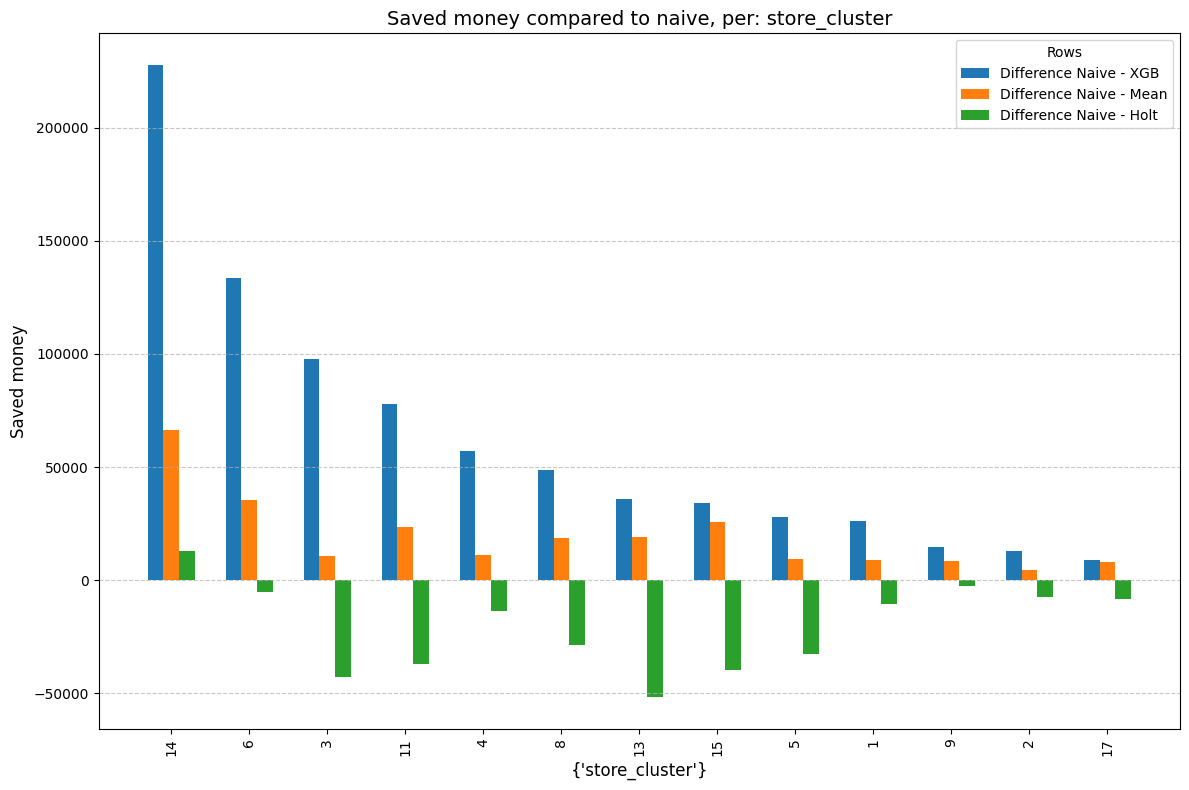

Processing group: store_nbr


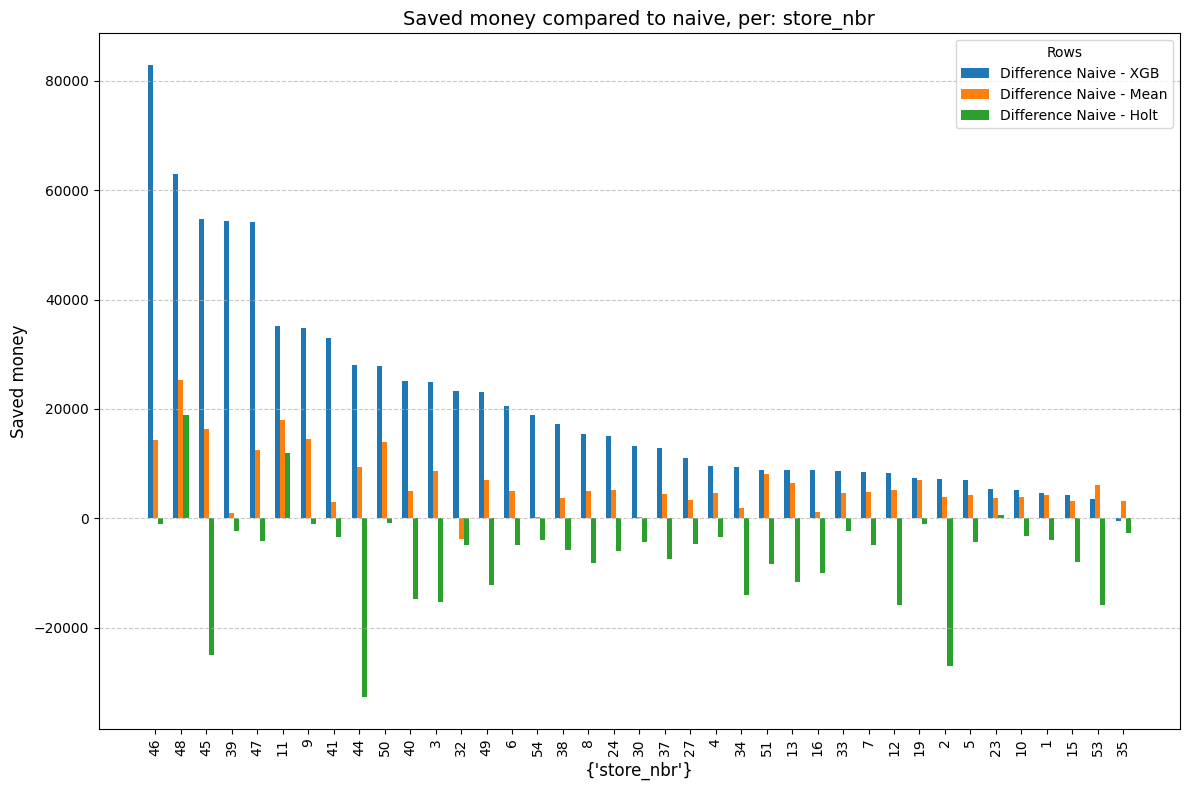

Processing group: perishable


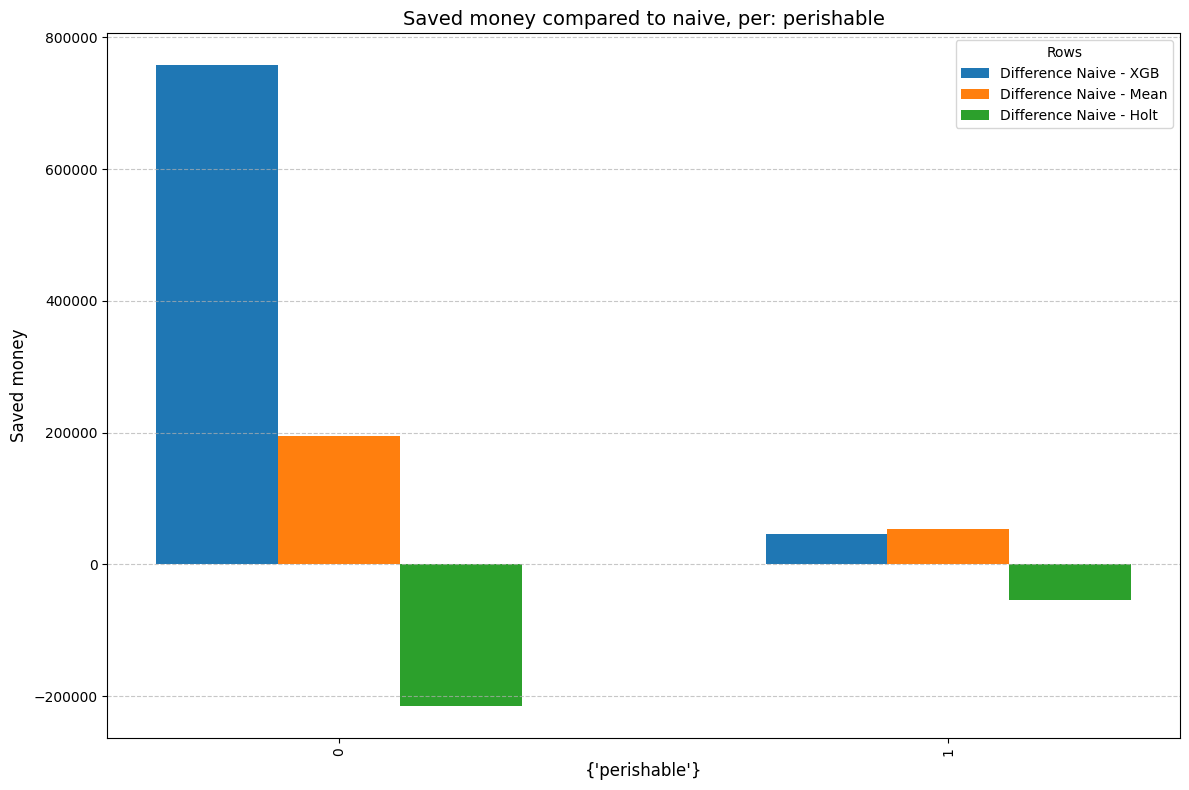

Processing group: item_family


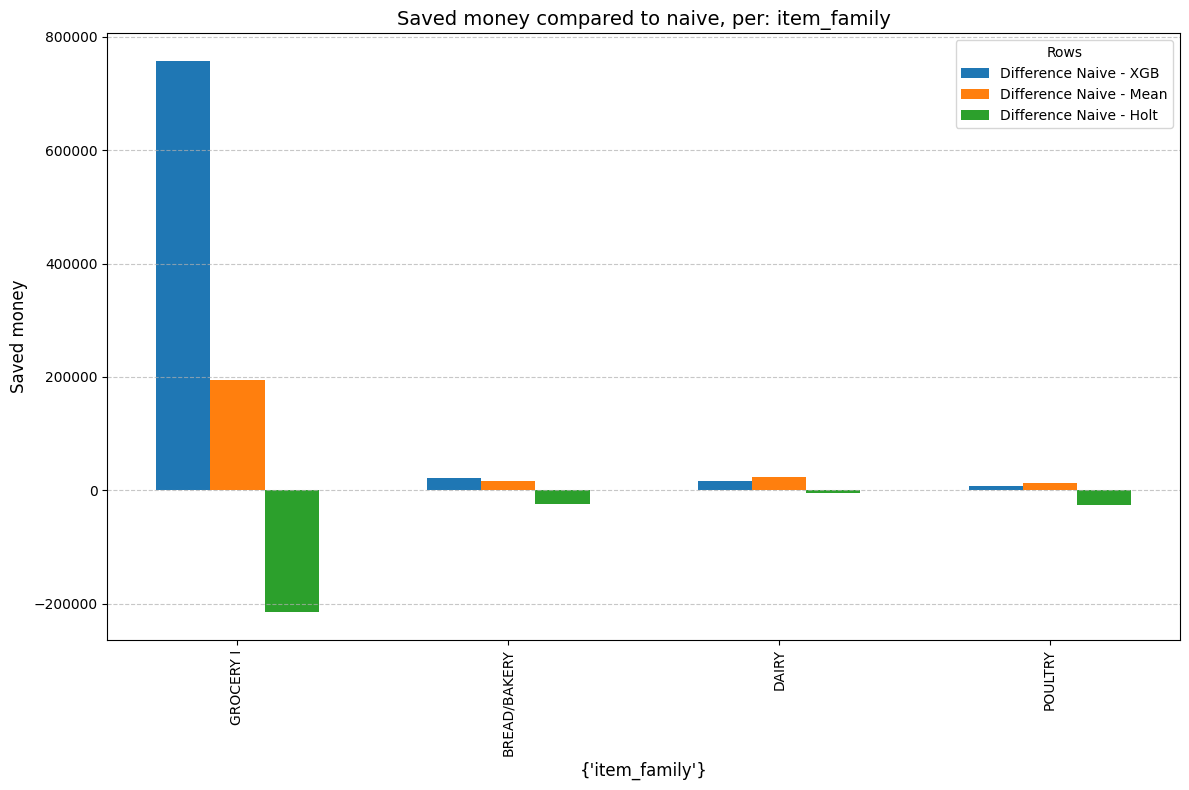

Processing group: item_class


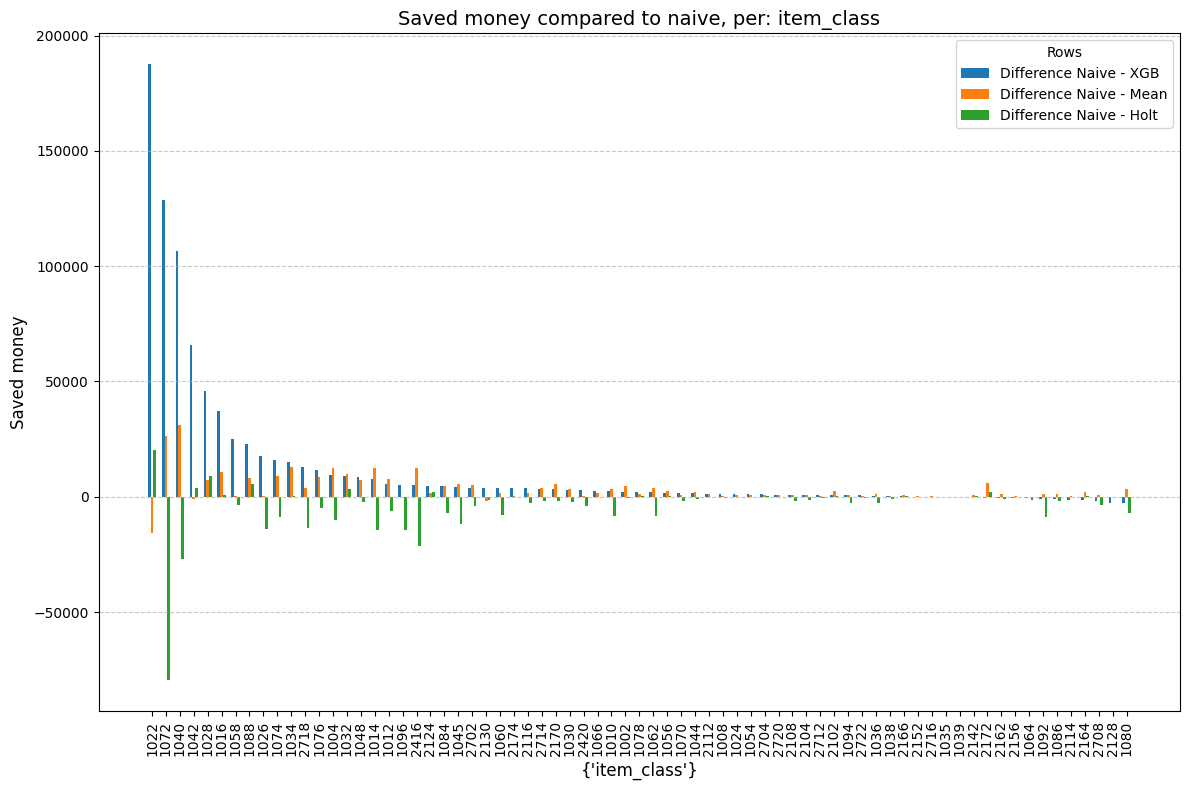

Processing group: week_number_cum


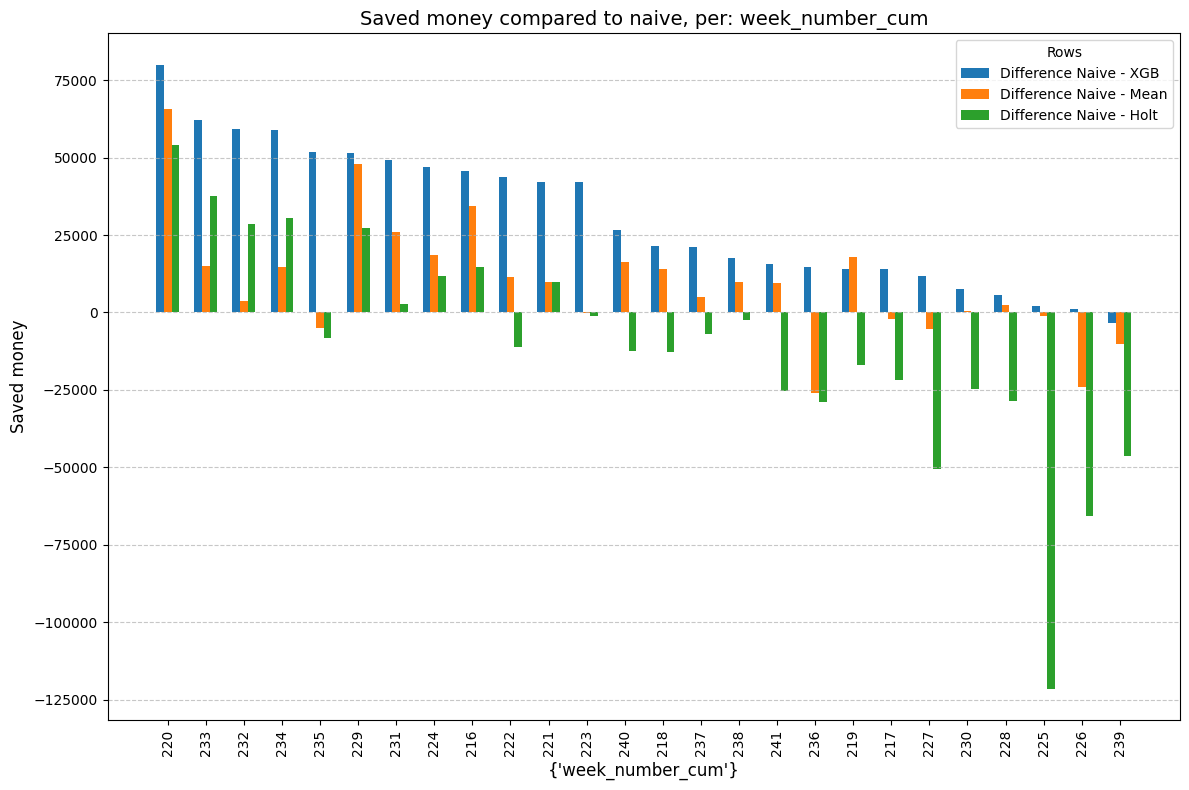

In [246]:
group_names = ['Difference Naive - XGB', 'Difference Naive - Mean', 'Difference Naive - Holt']
sorted_histogram(dict_df_metrics, group_names)

Line diagram of the cumulative saved costs compared to naive, per model

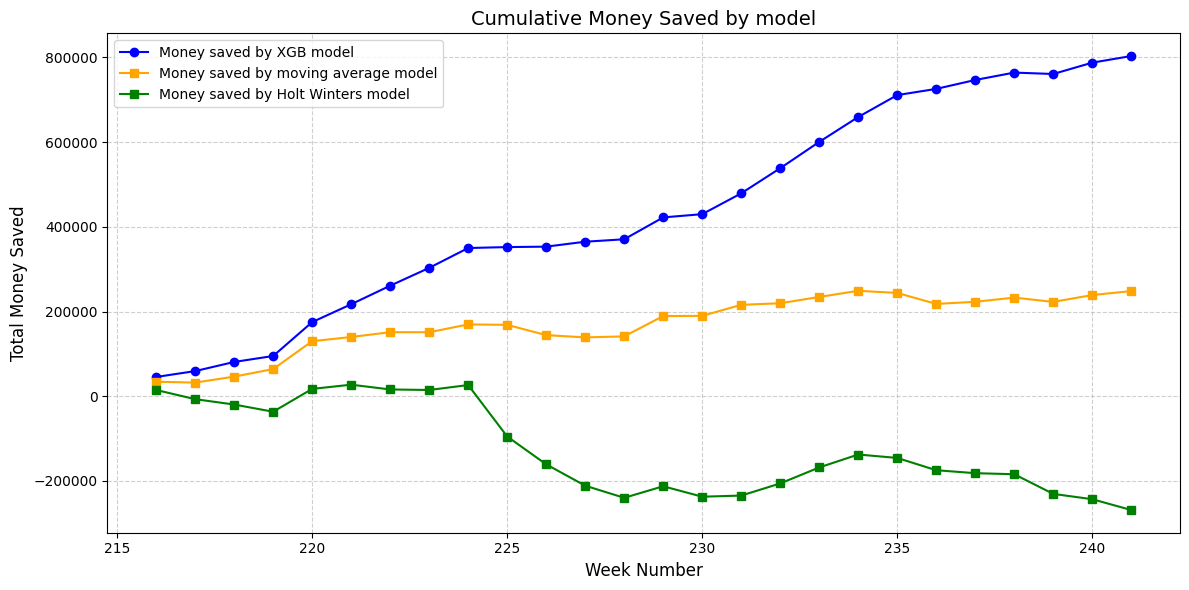

In [247]:
df_week_number_cum = calculate_metrics_grouped(df, 'week_number_cum')

# Assuming df_plot is the DataFrame you are working with
df_plot = df_week_number_cum

# Extract the row for "Difference Naive - XGB" and transpose it to work with it as a Series
difference_row_xgb = df_plot.loc['Difference Naive - XGB'].transpose()

# Extract the row for "Difference Naive - Mean" and transpose it to work with it as a Series
difference_row_mean = df_plot.loc['Difference Naive - Mean'].transpose()

# Extract the row for "Difference Naive - Holt" and transpose it to work with it as a Series
difference_row_holt = df_plot.loc['Difference Naive - Holt'].transpose()

# Ensure the index represents week numbers and the values are numeric
week_numbers = df_plot.columns.astype(int)  # Assuming column names are week numbers

# Convert the values for both rows to numeric, coercing any errors to NaN
difference_values_xgb = pd.to_numeric(difference_row_xgb, errors='coerce')
difference_values_mean = pd.to_numeric(difference_row_mean, errors='coerce')
difference_values_holt = pd.to_numeric(difference_row_holt, errors='coerce')

# Compute the cumulative sum of the difference values for both rows
cumulative_difference_xgb = difference_values_xgb.cumsum()
cumulative_difference_mean = difference_values_mean.cumsum()
cumulative_difference_holt = difference_values_holt.cumsum()

# Plot the cumulative difference for both "Difference Naive - XGB" and "Difference Naive - Mean"
plt.figure(figsize=(12, 6))

# Plot the cumulative difference for "Difference Naive - XGB"
plt.plot(week_numbers, cumulative_difference_xgb, marker='o', label='Money saved by XGB model', color='blue')

# Plot the cumulative difference for "Difference Naive - Mean"
plt.plot(week_numbers, cumulative_difference_mean, marker='s', label='Money saved by moving average model', color='orange')

# Plot the cumulative difference for "Difference Naive - Mean"
plt.plot(week_numbers, cumulative_difference_holt, marker='s', label='Money saved by Holt Winters model', color='green')

# Add labels and title
plt.title('Cumulative Money Saved by model', fontsize=14)
plt.xlabel('Week Number', fontsize=12)
plt.ylabel('Total Money Saved', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()


Import dataframes before validation to compare holt winters prediction with actuals

In [248]:
xgdf_train = pd.read_parquet('C:/Users/J.Heuvelmans/OneDrive - Brain Research Center/Documenten/EAISI/2024Supermarket/Data/processed/train_df_20241211.parquet', engine='pyarrow')
xgdf_test = pd.read_parquet('C:/Users/J.Heuvelmans/OneDrive - Brain Research Center/Documenten/EAISI/2024Supermarket/Data/processed/test_df_20241211.parquet', engine='pyarrow')

df_all = pd.concat([xgdf_train, xgdf_test, df_pred], axis=0, ignore_index=True)
df_all = df_all[df_all['week_number_cum'] >= 137]

df_all.info()
df_all

<class 'pandas.core.frame.DataFrame'>
Index: 1598730 entries, 51 to 2375255
Data columns (total 30 columns):
 #   Column            Non-Null Count    Dtype         
---  ------            --------------    -----         
 0   store_nbr         1598730 non-null  uint8         
 1   item_nbr          1598730 non-null  uint32        
 2   date              1598730 non-null  datetime64[ns]
 3   onpromotion       1202854 non-null  float64       
 4   store_type        1598730 non-null  object        
 5   store_cluster     1598730 non-null  uint8         
 6   item_family       1598730 non-null  object        
 7   item_class        1598730 non-null  uint16        
 8   perishable        1598730 non-null  uint8         
 9   year              1202854 non-null  float64       
 10  week_number_cum   1598730 non-null  int16         
 11  unit_sales        1598730 non-null  float32       
 12  unique_id         395876 non-null   float64       
 13  y_naive           395876 non-null   float32   

,store_nbr,item_nbr,date,onpromotion,store_type,store_cluster,item_family,item_class,perishable,year,...,bias_y_mean,acc_y_mean,adj_bias_y_mean,bias_y_naive,acc_y_naive,adj_bias_y_naive,bias_y_holt,acc_y_holt,adj_bias_y_holt,uniqueID
51,1,105857,2015-08-10,0.000000,D,13,GROCERY I,1092,0,2015.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
52,1,105857,2015-08-17,0.000000,D,13,GROCERY I,1092,0,2015.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
53,1,105857,2015-08-24,0.000000,D,13,GROCERY I,1092,0,2015.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54,1,105857,2015-08-31,0.000000,D,13,GROCERY I,1092,0,2015.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
55,1,105857,2015-09-07,0.000000,D,13,GROCERY I,1092,0,2015.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2375251,54,1324670,2017-07-10,NaN,C,3,GROCERY I,1094,0,NaN,...,8.023809,66.567463,5.349206,18.833332,21.527784,12.555554,-0.287274,98.803023,0.095758,54_1324670
2375252,54,1324670,2017-07-17,NaN,C,3,GROCERY I,1094,0,NaN,...,-3.500001,89.393937,1.166667,-10.000000,69.696968,3.333333,-13.848173,58.035838,4.616058,54_1324670
2375253,54,1324670,2017-07-24,NaN,C,3,GROCERY I,1094,0,NaN,...,7.801587,64.767024,5.201058,1.857143,91.612900,1.238096,10.671865,51.804478,7.114577,54_1324670
2375254,54,1324670,2017-07-31,NaN,C,3,GROCERY I,1094,0,NaN,...,4.666667,78.787879,3.111111,11.000000,50.000000,7.333333,2.651683,87.946894,1.767789,54_1324670


In [249]:
# Group by 'item' and 'store' and sum the 'unit_sales'
sales_per_item_store = df_all.groupby(['item_nbr', 'store_nbr'])['unit_sales'].sum().reset_index()

# Find the combination with the highest unit sales
max_sales_combination = sales_per_item_store.loc[sales_per_item_store['unit_sales'].idxmax()]

print("Highest Unit Sales Combination:")
print(max_sales_combination)

Highest Unit Sales Combination:
item_nbr     903285.000000
store_nbr        47.000000
unit_sales   119971.898438
Name: 10011, dtype: float64


Graph of total sales of total time period

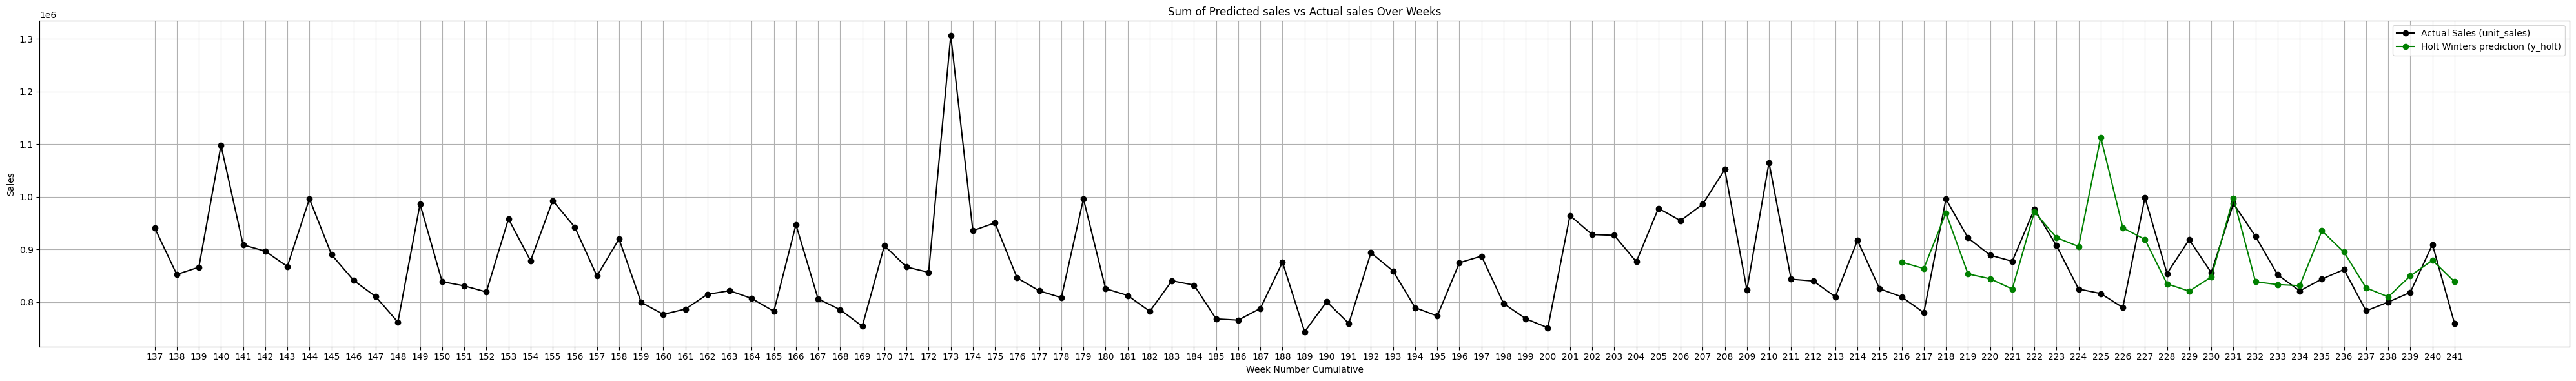

In [250]:
    grouped_df = df_all
    # Step 2: Group by 'week_number_cum' and compute the sum for each of the columns
    grouped_df = grouped_df.groupby('week_number_cum')[['y_xgb', 'unit_sales', 'y_naive', 'y_mean', 'y_holt']].sum(min_count=1).reset_index()

    # Step 3: Plot the results
    plt.figure(figsize=(40, 6))
    # plt.plot(grouped_df['week_number_cum'], grouped_df['y_xgb'], marker='o', label='XGB prediction (y_xgb)', color='blue')
    plt.plot(grouped_df['week_number_cum'], grouped_df['unit_sales'], marker='o', label='Actual Sales (unit_sales)', color='black')
    # plt.plot(grouped_df['week_number_cum'], grouped_df['y_naive'], marker='o', label='Naive prediction (y_naive)', color='red')
    # plt.plot(grouped_df['week_number_cum'], grouped_df['y_mean'], marker='o', label='Average mean prediction (y_mean)', color='orange')
    plt.plot(grouped_df['week_number_cum'], grouped_df['y_holt'], marker='o', label='Holt Winters prediction (y_holt)', color='green')

    # Add titles and labels
    plt.title(f'Sum of Predicted sales vs Actual sales Over Weeks')
    plt.xlabel('Week Number Cumulative')
    plt.ylabel('Sales')
    plt.xticks(grouped_df['week_number_cum'])  # Set x-ticks to show all weeks
    plt.legend()
    plt.grid()

    # Show the plot
    plt.tight_layout()
    plt.show()

Function to plot per column the sum of sales (item_nbr, item_family, store_type etc). Goal is to compare Holt Winters predictions with actuals

In [251]:
def plot_sales_comparison_holt(df, filter_column, filter_value):
    """
    Plots a comparison of predicted sales (y_xgb), actual sales (unit_sales), and naive predictions (y_naive)
    over weeks for a specified store (or any other column-based filter).

    Parameters:
    df_pred (pd.DataFrame): DataFrame containing the data.
    filter_column (str): The column name to filter by (e.g., 'store_nbr').
    filter_value (int or str): The value to filter the specified column by (e.g., a store number).
    """
    # Step 1: Filter data for the specified column and value
    grouped_df = df[df[filter_column] == filter_value]

    # Step 2: Group by 'week_number_cum' and compute the sum for each of the columns
    grouped_df = grouped_df.groupby('week_number_cum')[['y_xgb', 'unit_sales', 'y_naive', 'y_mean', 'y_holt']].sum(min_count=1).reset_index()

    # Step 3: Plot the results
    plt.figure(figsize=(40, 6))
    # plt.plot(grouped_df['week_number_cum'], grouped_df['y_xgb'], marker='o', label='XGB prediction (y_xgb)', color='blue')
    plt.plot(grouped_df['week_number_cum'], grouped_df['unit_sales'], marker='o', label='Actual Sales (unit_sales)', color='black')
    # plt.plot(grouped_df['week_number_cum'], grouped_df['y_naive'], marker='o', label='Naive prediction (y_naive)', color='red')
    # plt.plot(grouped_df['week_number_cum'], grouped_df['y_mean'], marker='o', label='Average mean prediction (y_mean)', color='orange')
    plt.plot(grouped_df['week_number_cum'], grouped_df['y_holt'], marker='o', label='Holt Winters prediction (y_holt)', color='green')

    # Add titles and labels
    plt.title(f'Sum of Predicted sales vs Actual sales Over Weeks for {filter_column} = {filter_value}')
    plt.xlabel('Week Number Cumulative')
    plt.ylabel('Sales')
    plt.xticks(grouped_df['week_number_cum'])  # Set x-ticks to show all weeks
    plt.legend()
    plt.grid()

    # Show the plot
    plt.tight_layout()
    plt.show()

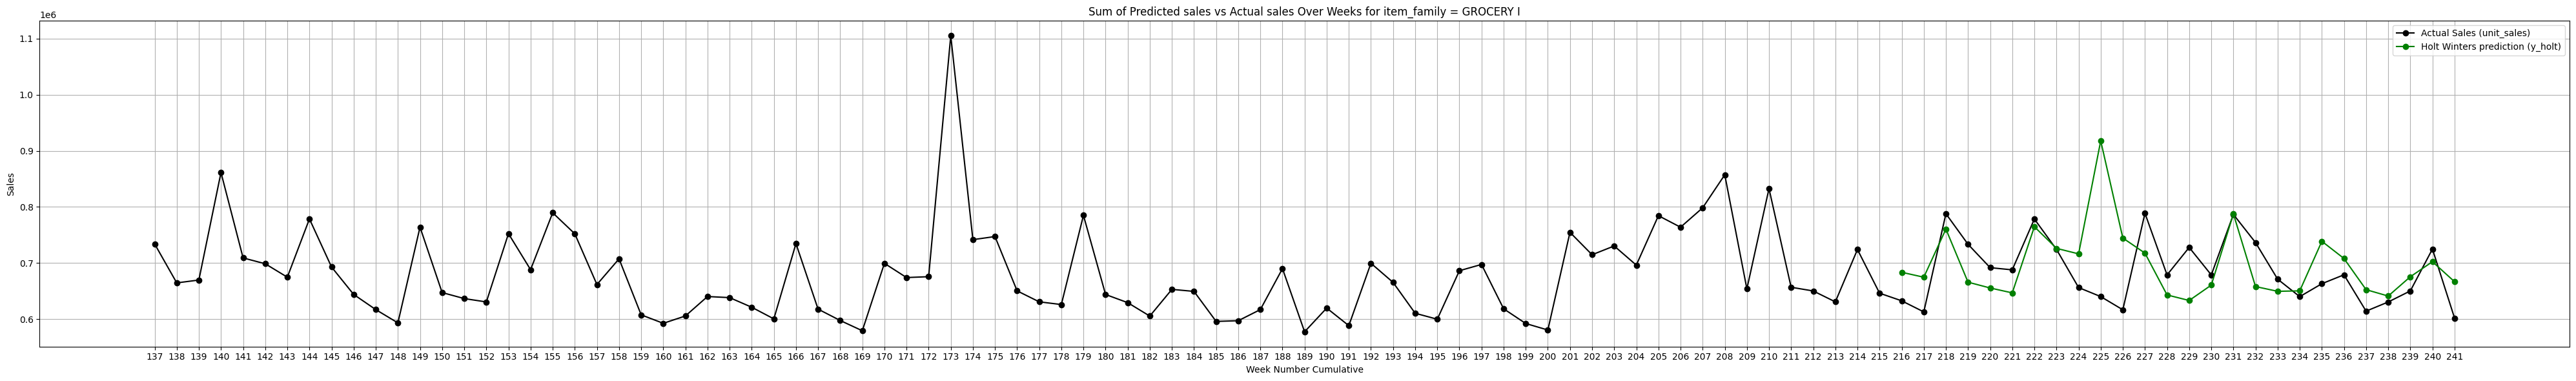

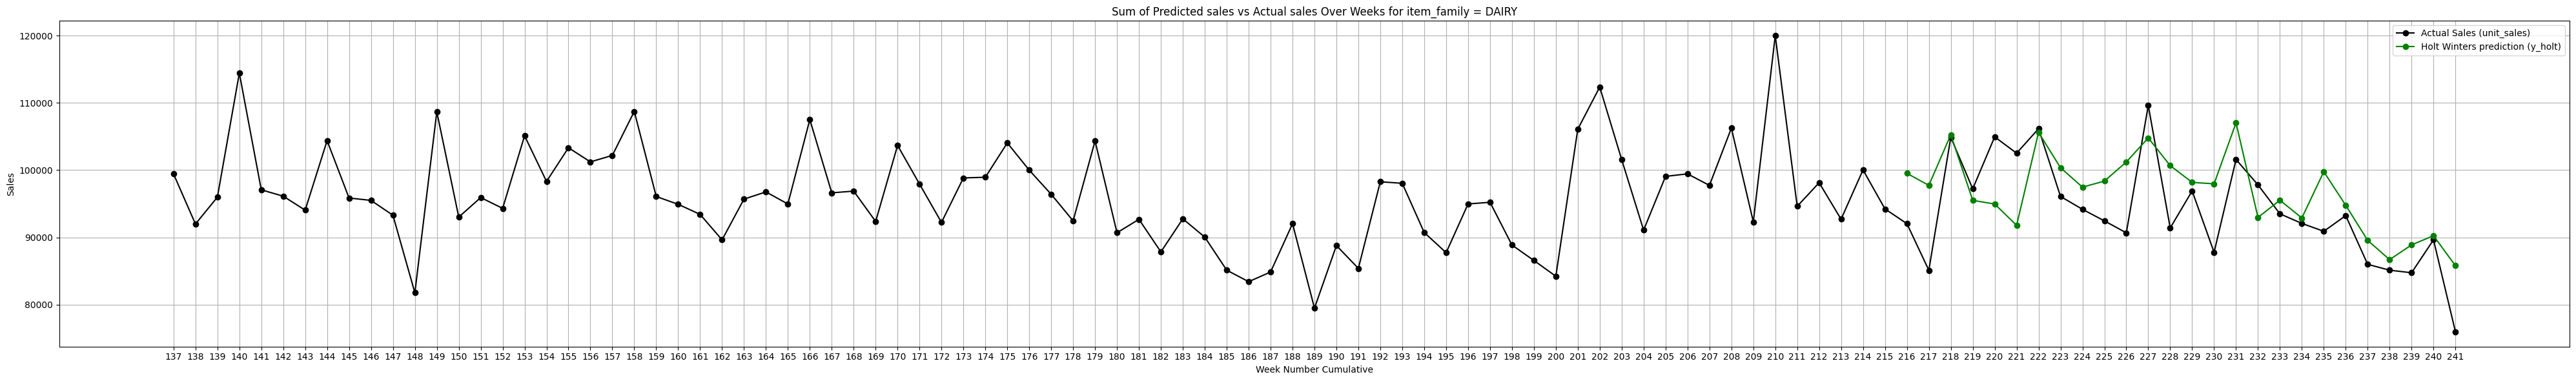

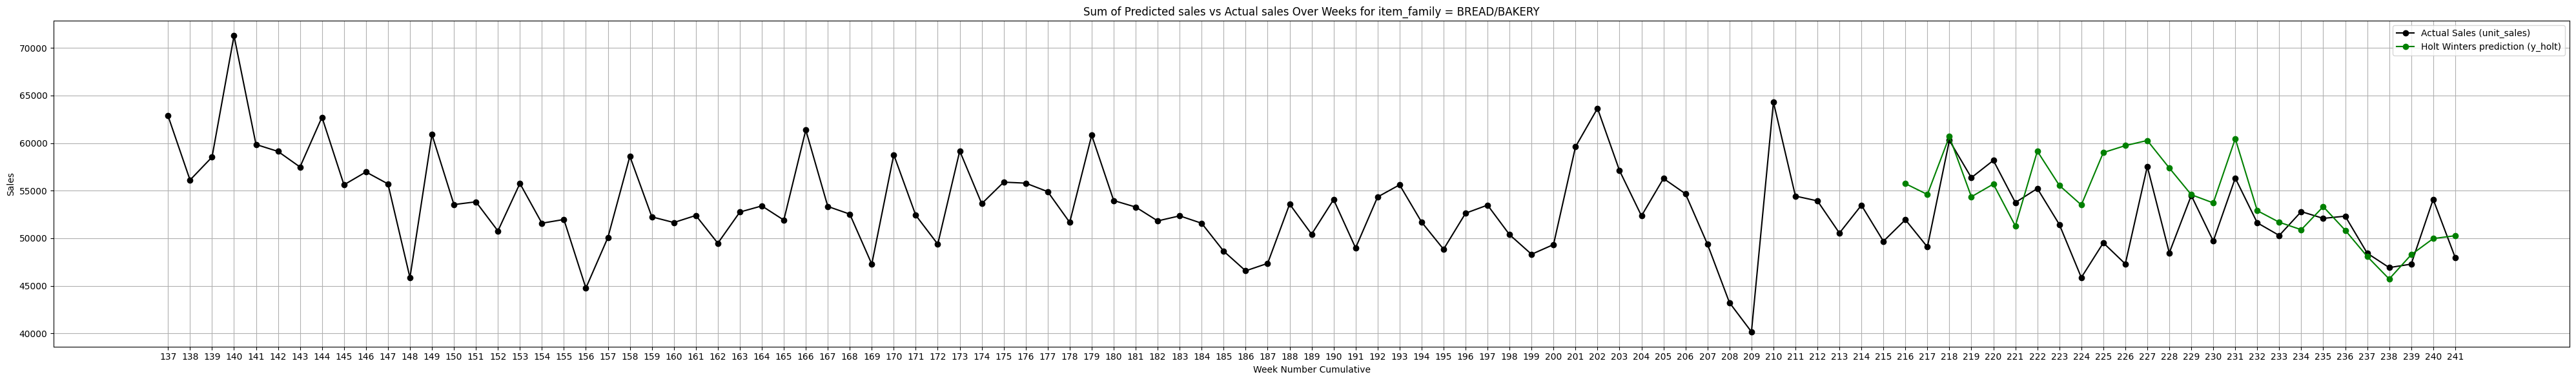

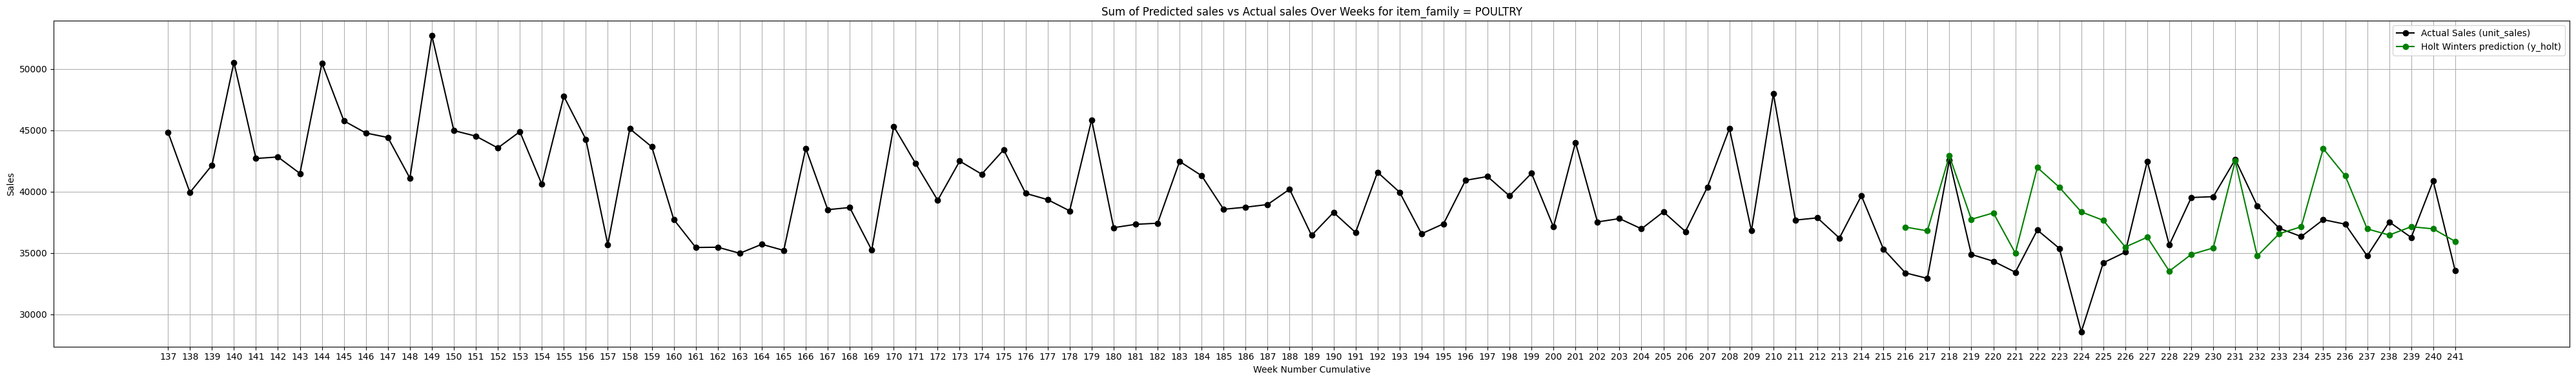

In [252]:

column = 'item_family'
# Get unique values in the current column
unique_values = df_all[column].unique()
    
# Loop through each unique value in the column
for value in unique_values:
    # Call the plot_sales_comparison function
    plot_sales_comparison_holt(df_all, filter_column=column, filter_value=value)

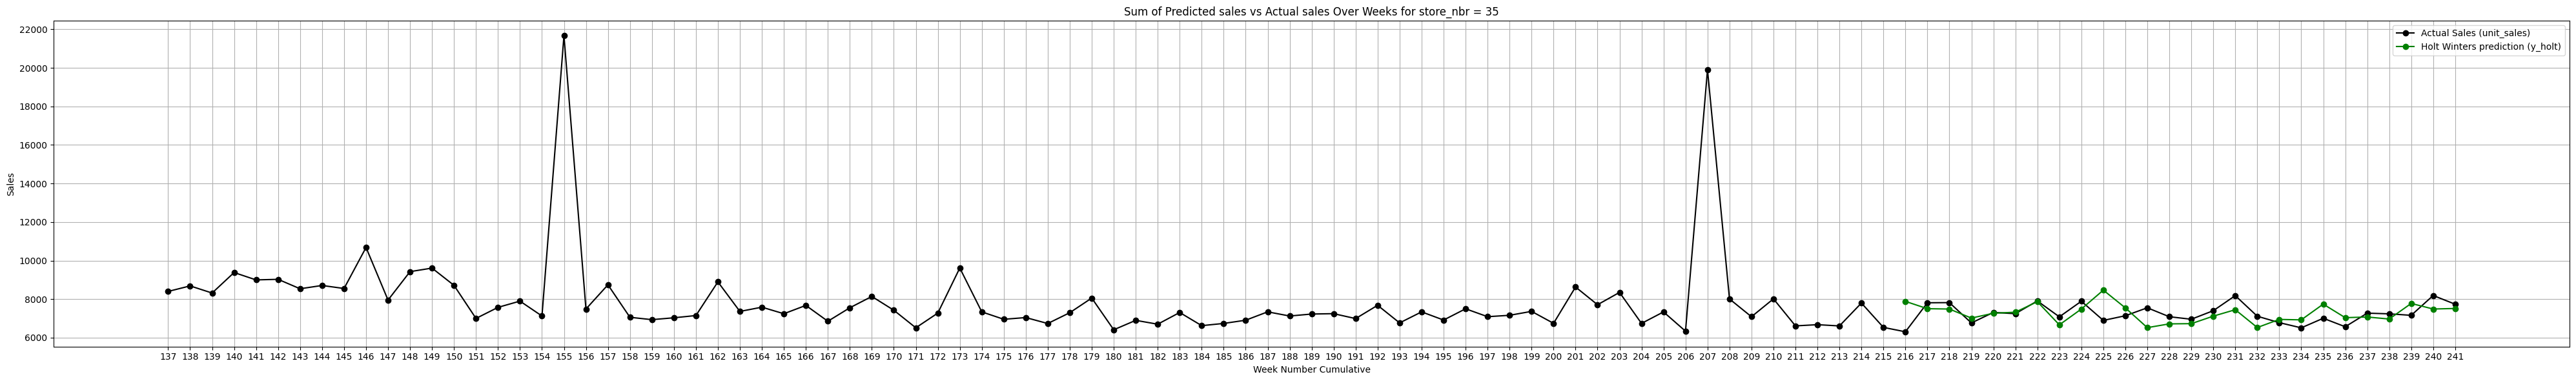

In [253]:
# Plot for best performing store 35
plot_sales_comparison_holt(df_all, filter_column='store_nbr', filter_value=35)

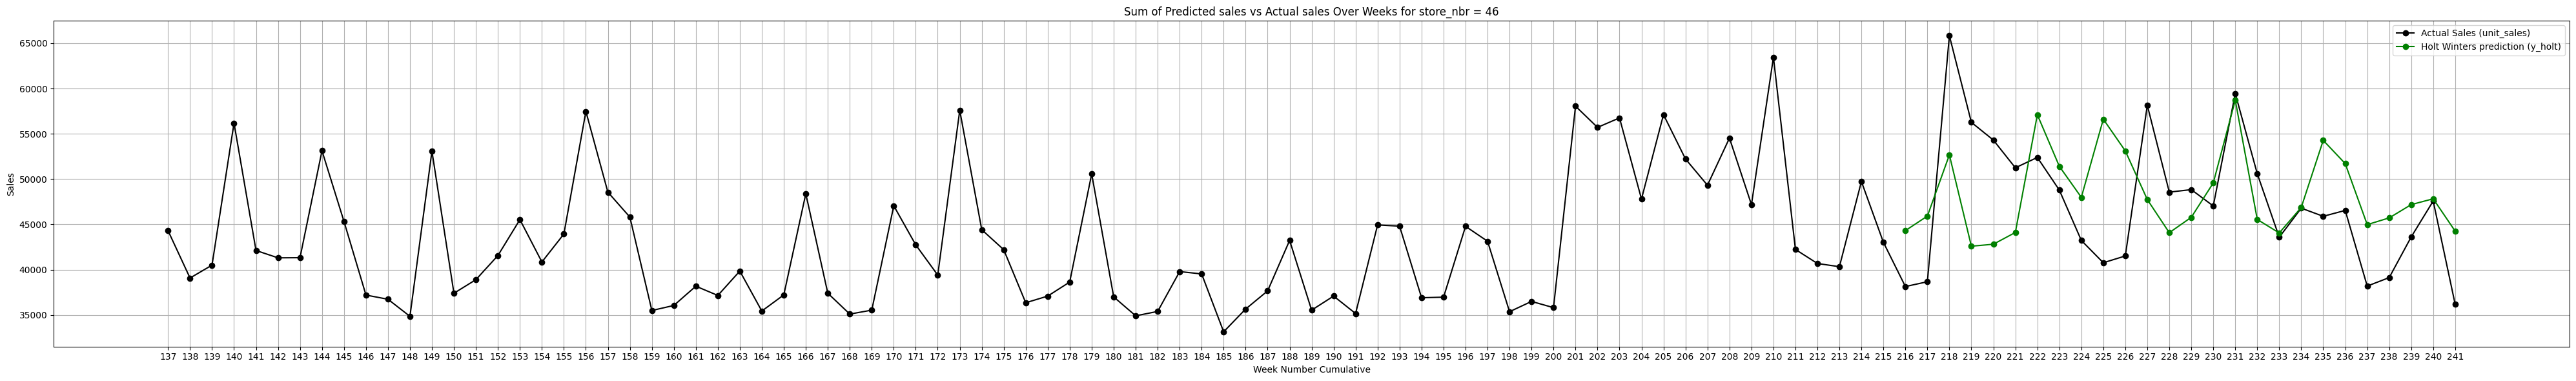

In [254]:
# Plot for least performing store 46
plot_sales_comparison_holt(df_all, filter_column='store_nbr', filter_value=46)

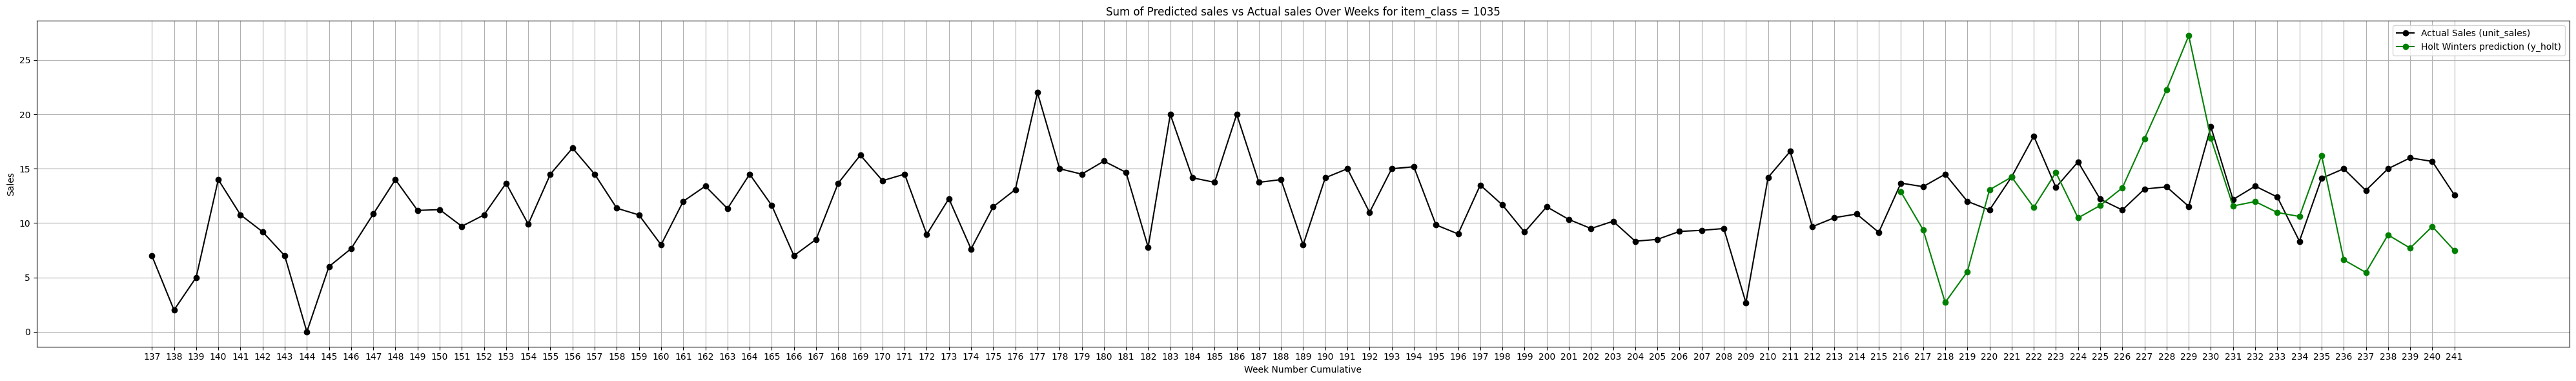

In [255]:
# Plot for best performing item_class 1035
plot_sales_comparison_holt(df_all, filter_column='item_class', filter_value=1035)

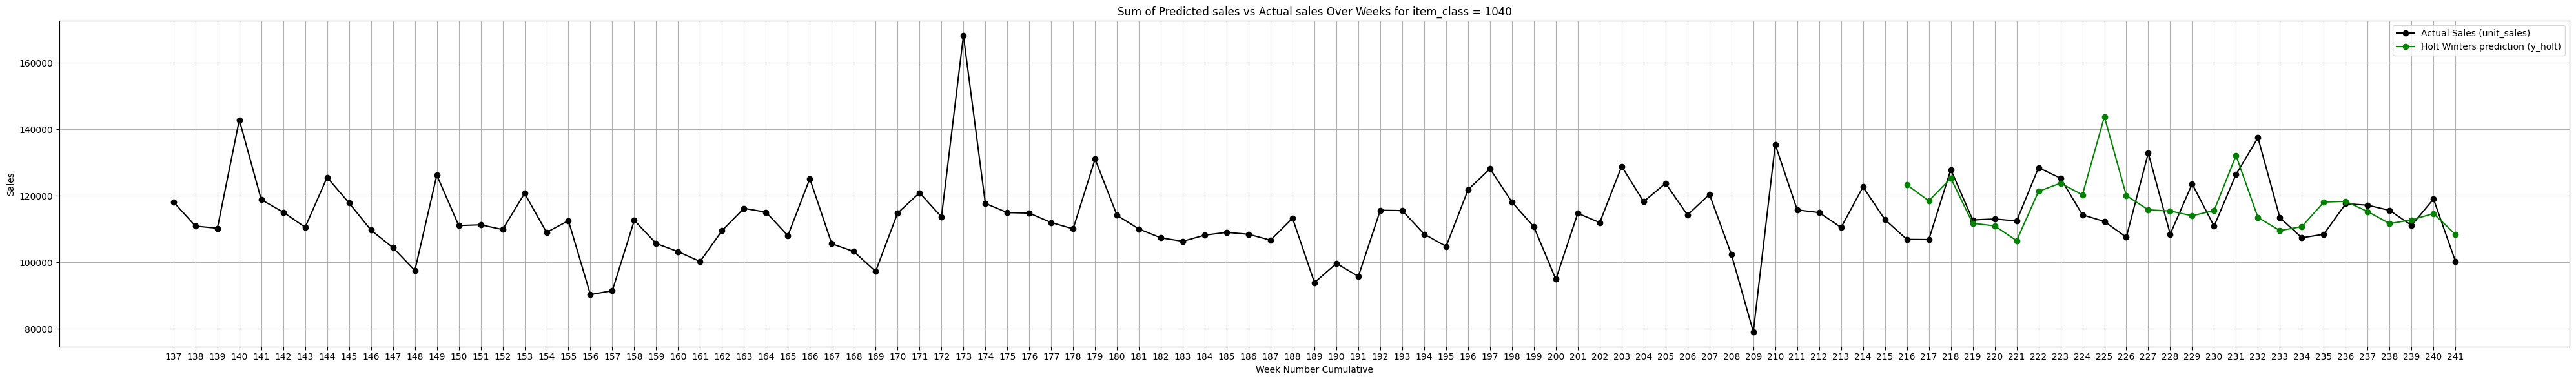

In [256]:
# Plot for least performing item_class 1040
plot_sales_comparison_holt(df_all, filter_column='item_class', filter_value=1040)

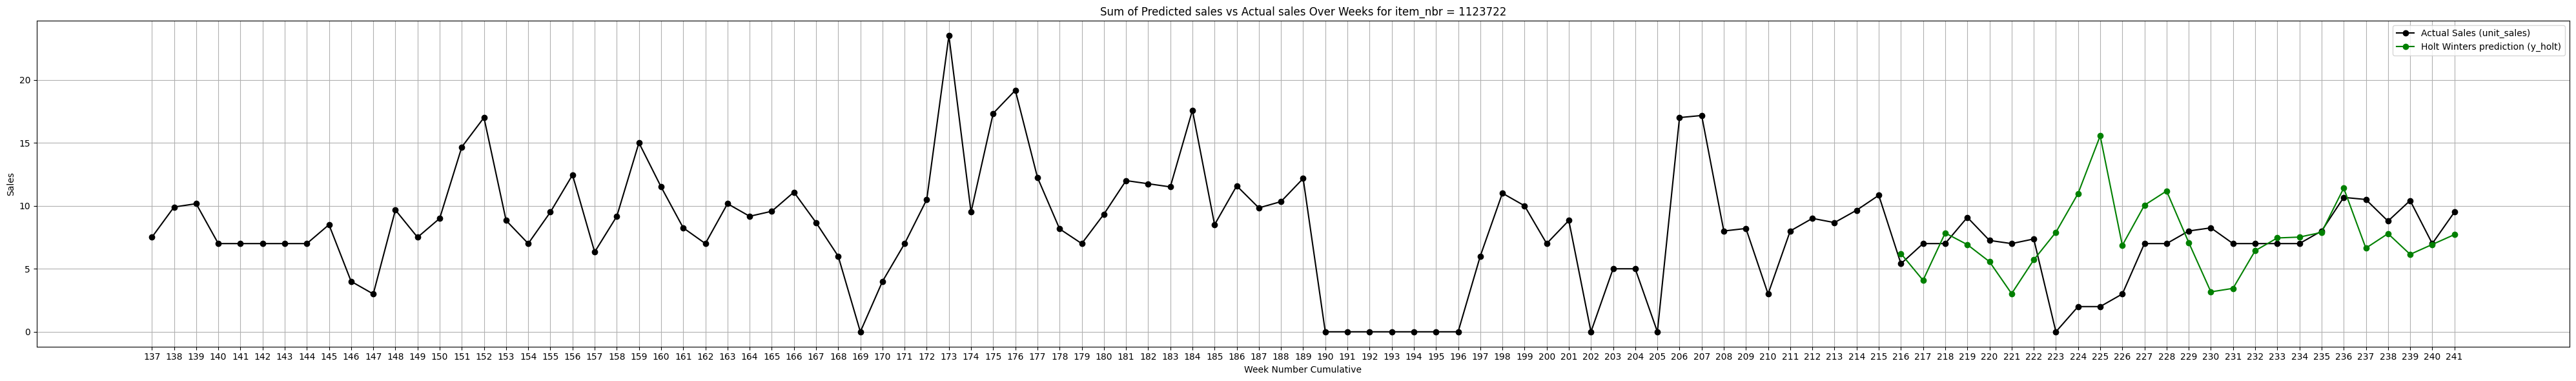

In [257]:
# Plot for best performing item_nbr 1123722
plot_sales_comparison_holt(df_all, filter_column='item_nbr', filter_value=1123722)

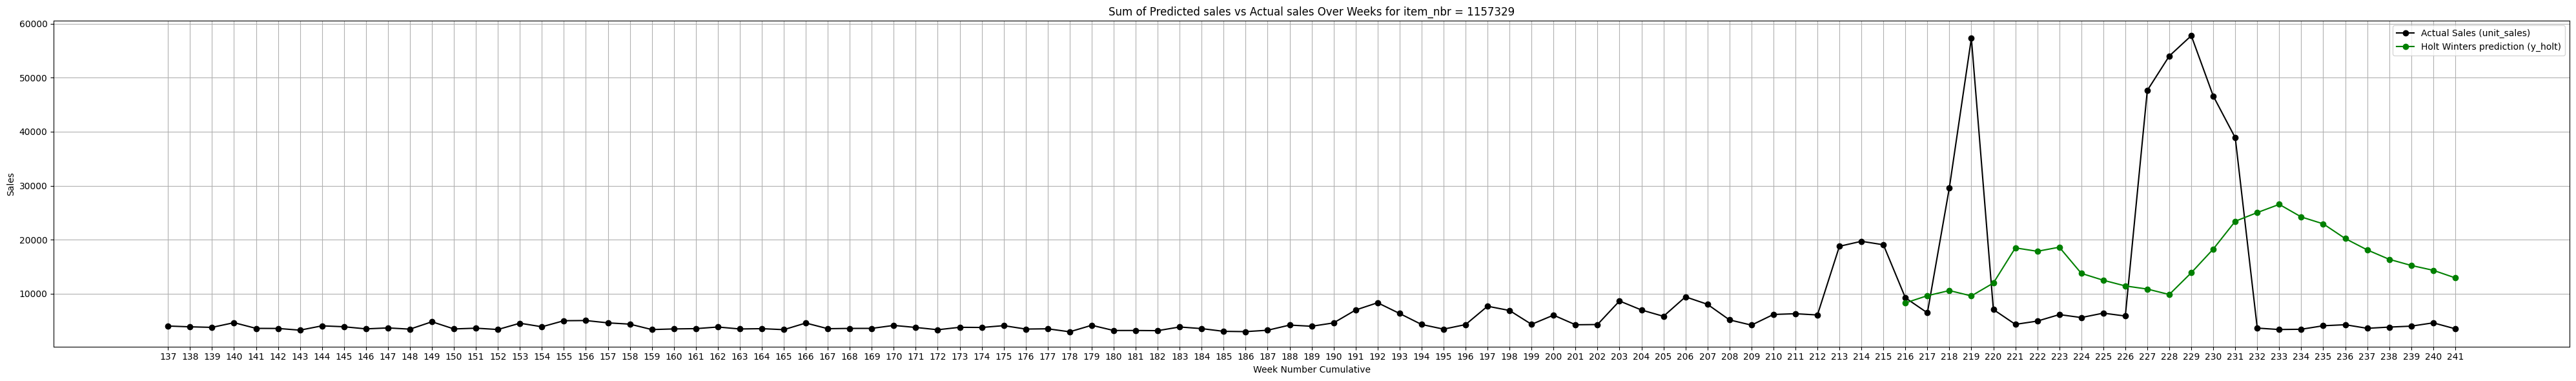

In [258]:
# Plot for least performing item_nbr 1157329
plot_sales_comparison_holt(df_all, filter_column='item_nbr', filter_value=1157329)

Below option to plot sales for item-store combination of choice, holt-winters

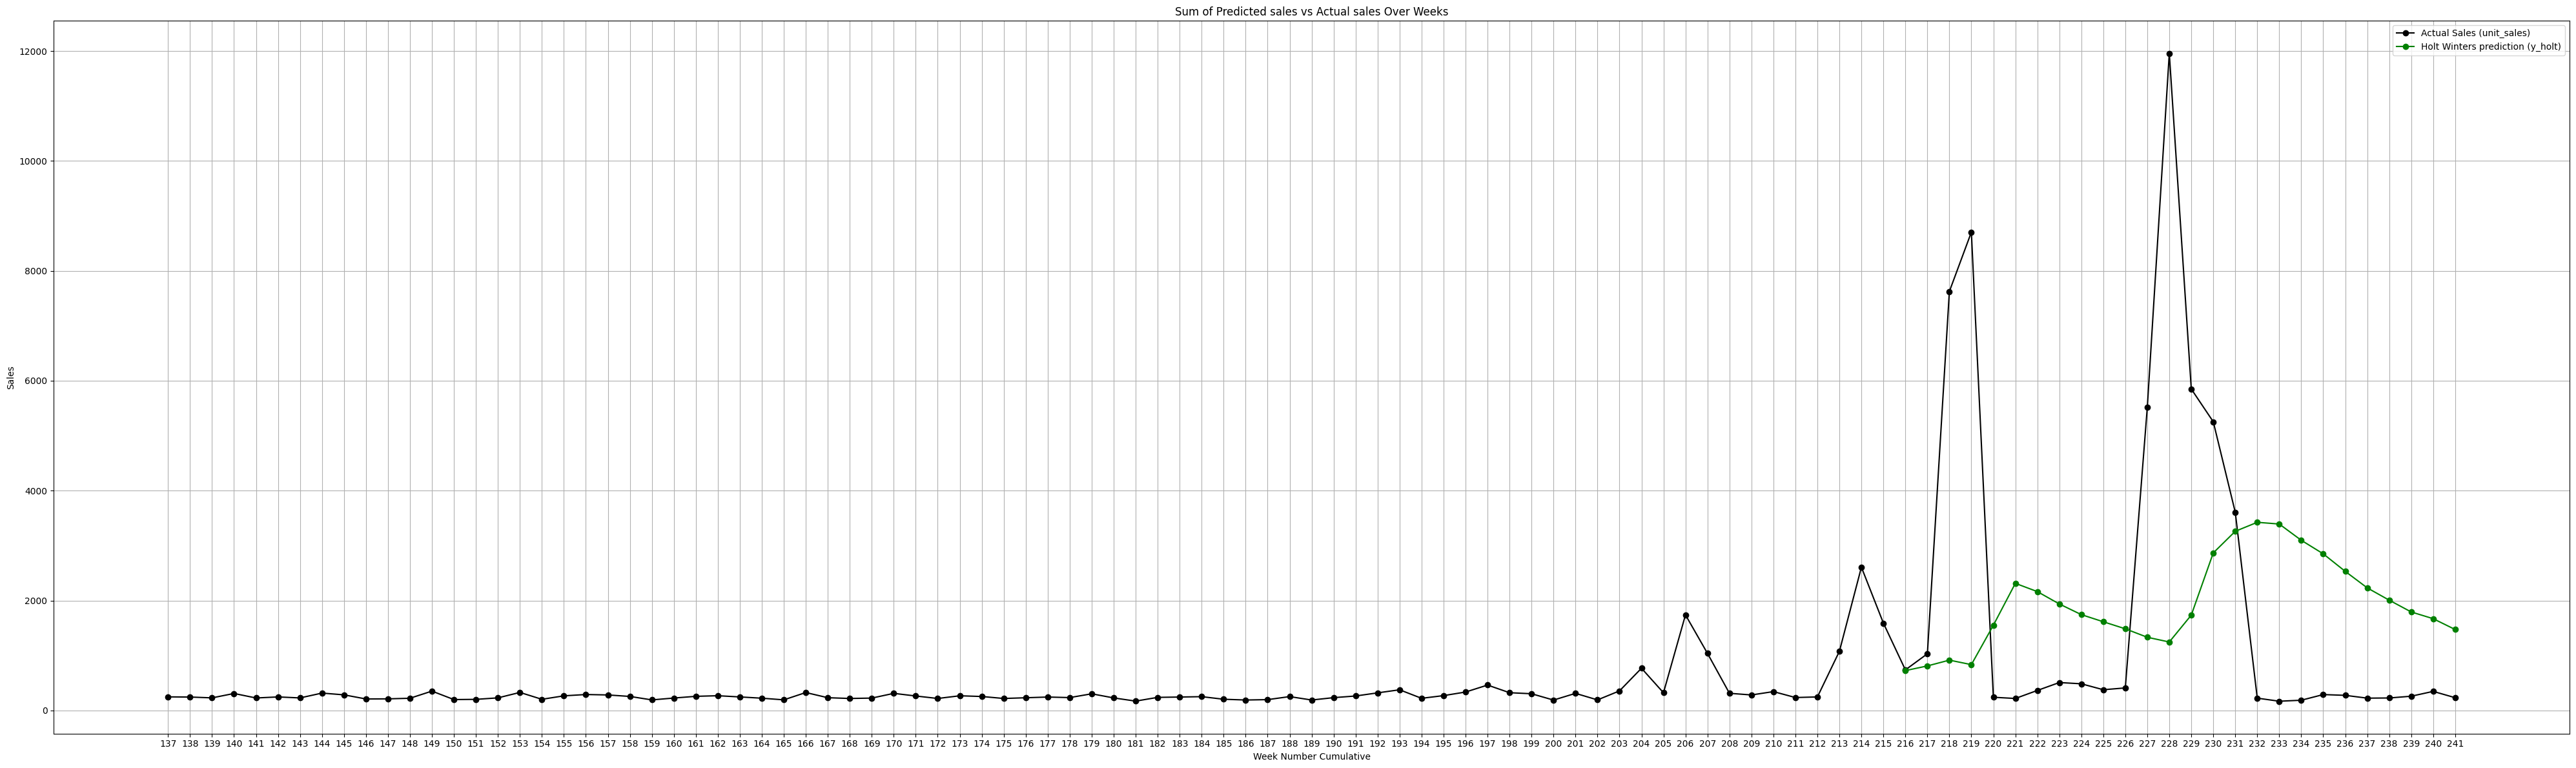

In [259]:
    # Choose store_nbr
    store = 46
    # Choose item_nbr 
    item = 1157329  

    grouped_df = df_all[(df_all['store_nbr'] == store) & (df_all['item_nbr'] == item)]

    grouped_df = grouped_df.groupby('week_number_cum')[['y_xgb', 'unit_sales', 'y_naive', 'y_mean', 'y_holt']].sum(min_count=1).reset_index()

    # Step 3: Plot the results
    plt.figure(figsize=(40, 12))
    # plt.plot(grouped_df['week_number_cum'], grouped_df['y_xgb'], marker='o', label='XGB prediction (y_xgb)', color='blue')
    plt.plot(grouped_df['week_number_cum'], grouped_df['unit_sales'], marker='o', label='Actual Sales (unit_sales)', color='black')
    # plt.plot(grouped_df['week_number_cum'], grouped_df['y_naive'], marker='o', label='Naive prediction (y_naive)', color='red')
    # plt.plot(grouped_df['week_number_cum'], grouped_df['y_mean'], marker='o', label='Average mean prediction (y_mean)', color='orange')
    plt.plot(grouped_df['week_number_cum'], grouped_df['y_holt'], marker='o', label='Holt Winters prediction (y_holt)', color='green')

    # Add titles and labels
    plt.title(f'Sum of Predicted sales vs Actual sales Over Weeks')
    plt.xlabel('Week Number Cumulative')
    plt.ylabel('Sales')
    plt.xticks(grouped_df['week_number_cum'])  # Set x-ticks to show all weeks
    plt.legend()
    plt.grid()

    # Show the plot
    plt.tight_layout()
    plt.show()

Graphs for the best and least performing store-item combinations:

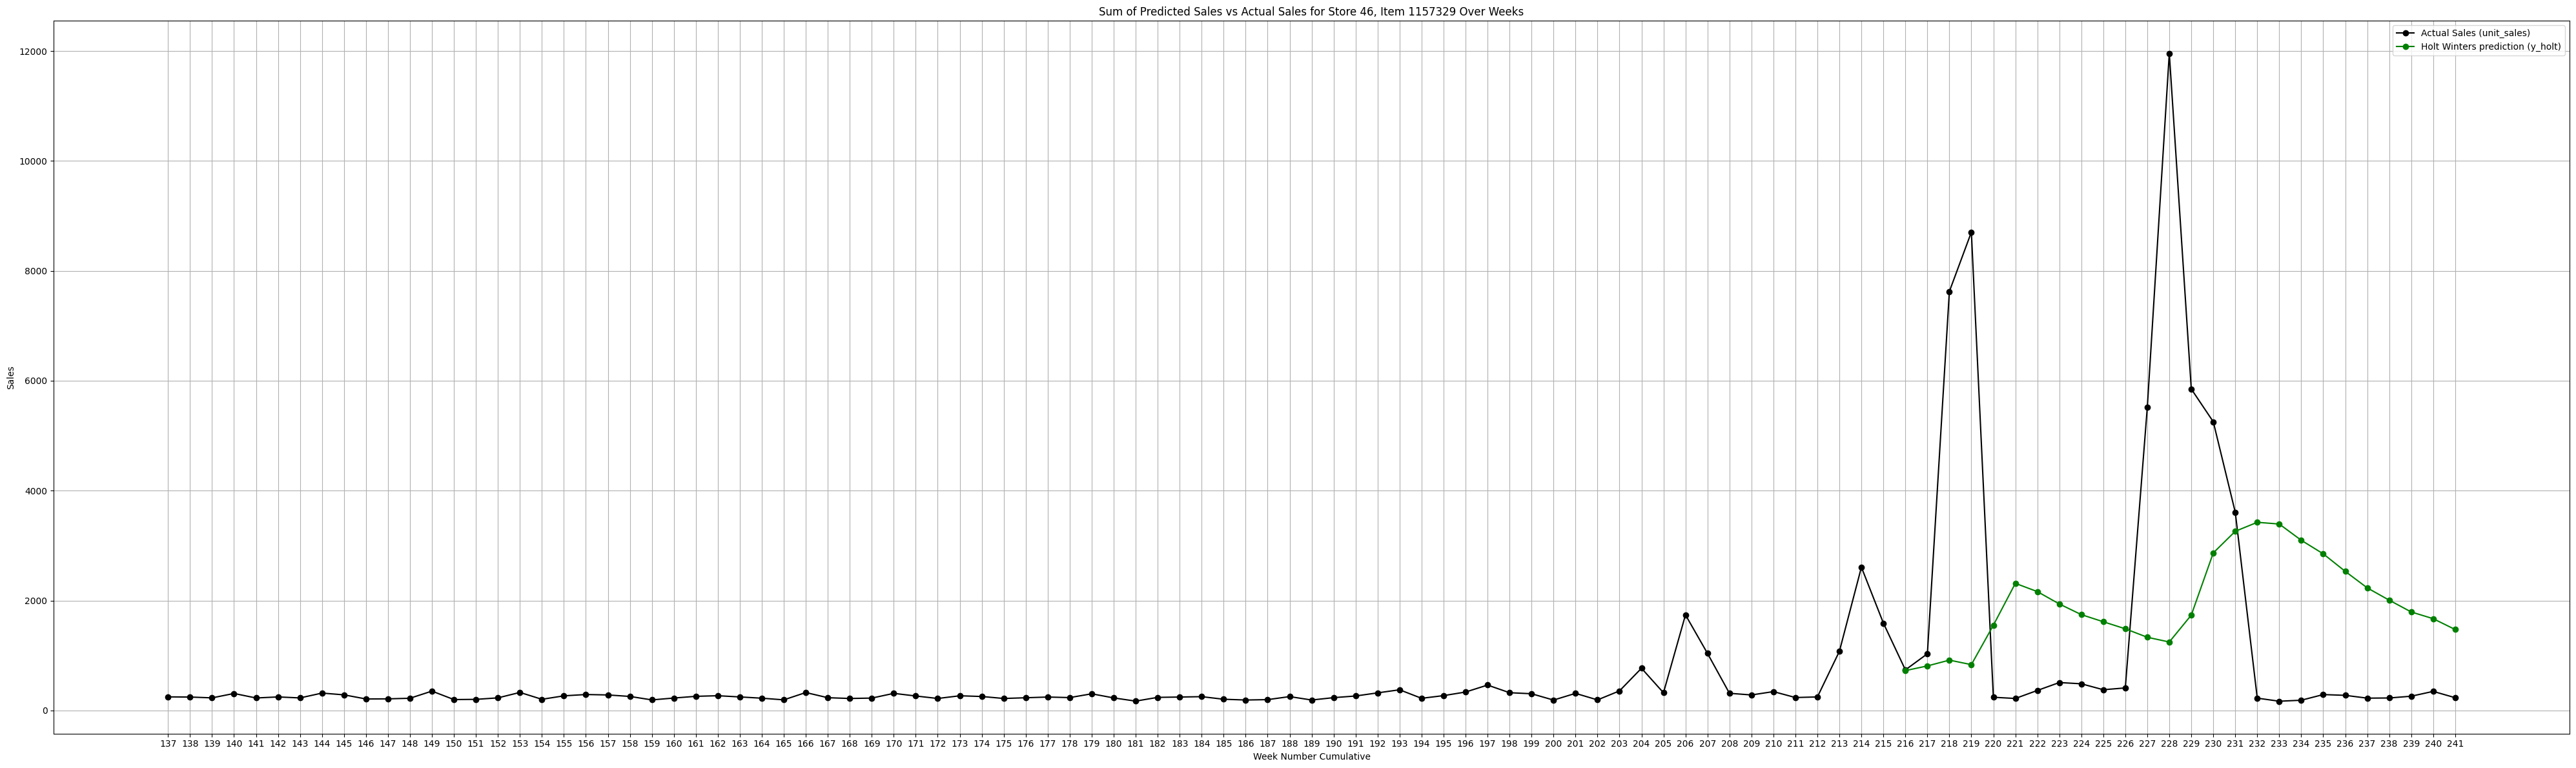

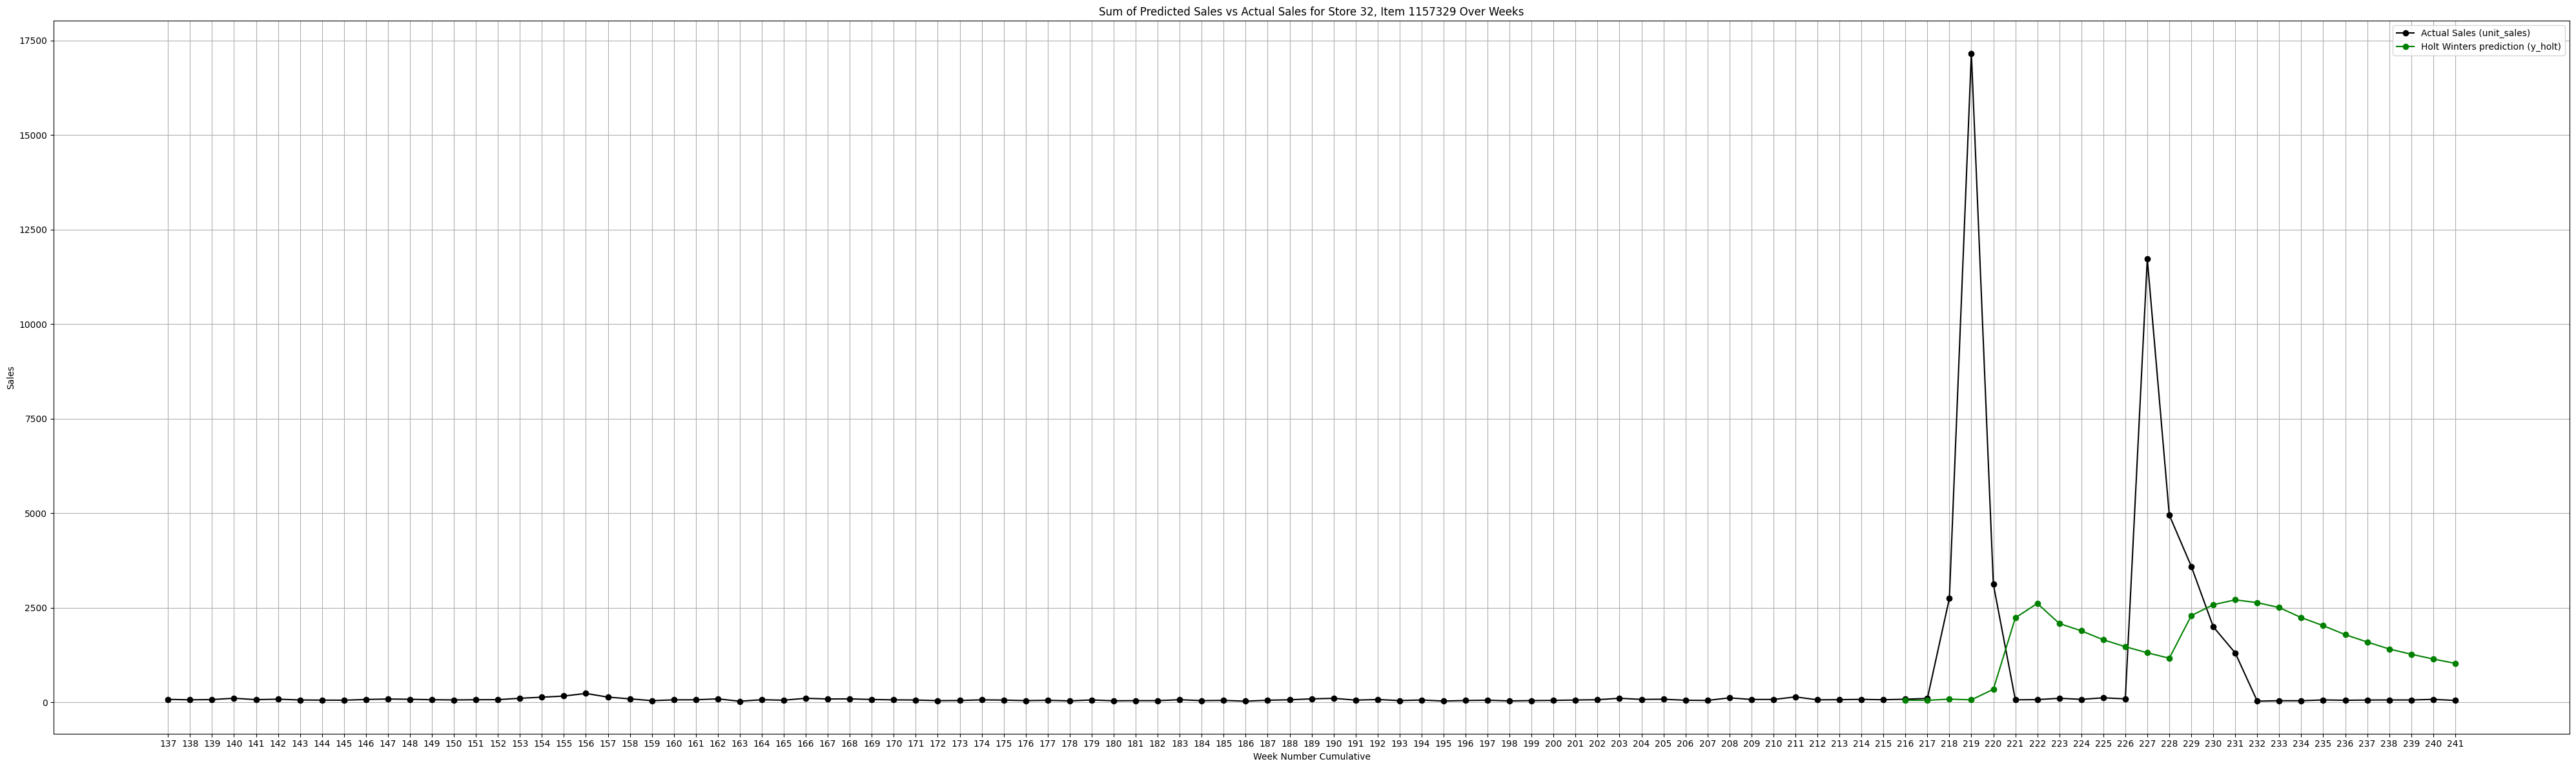

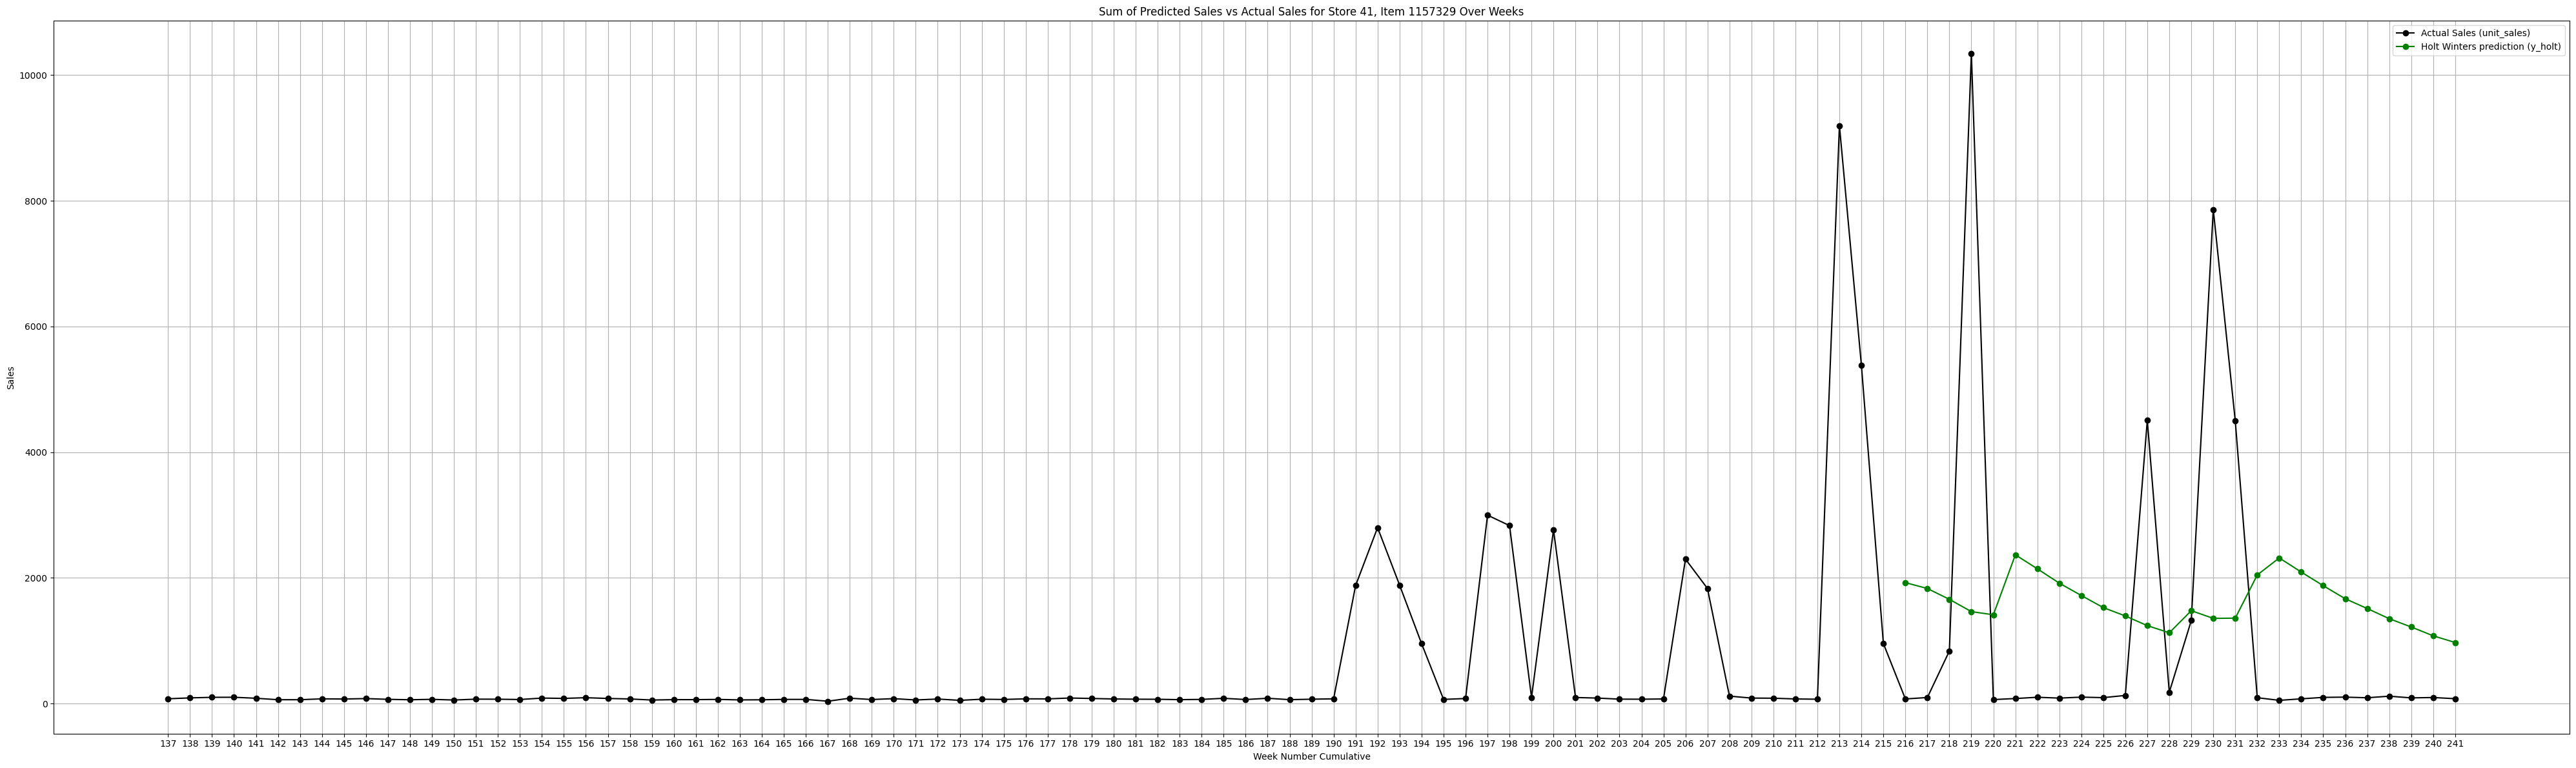

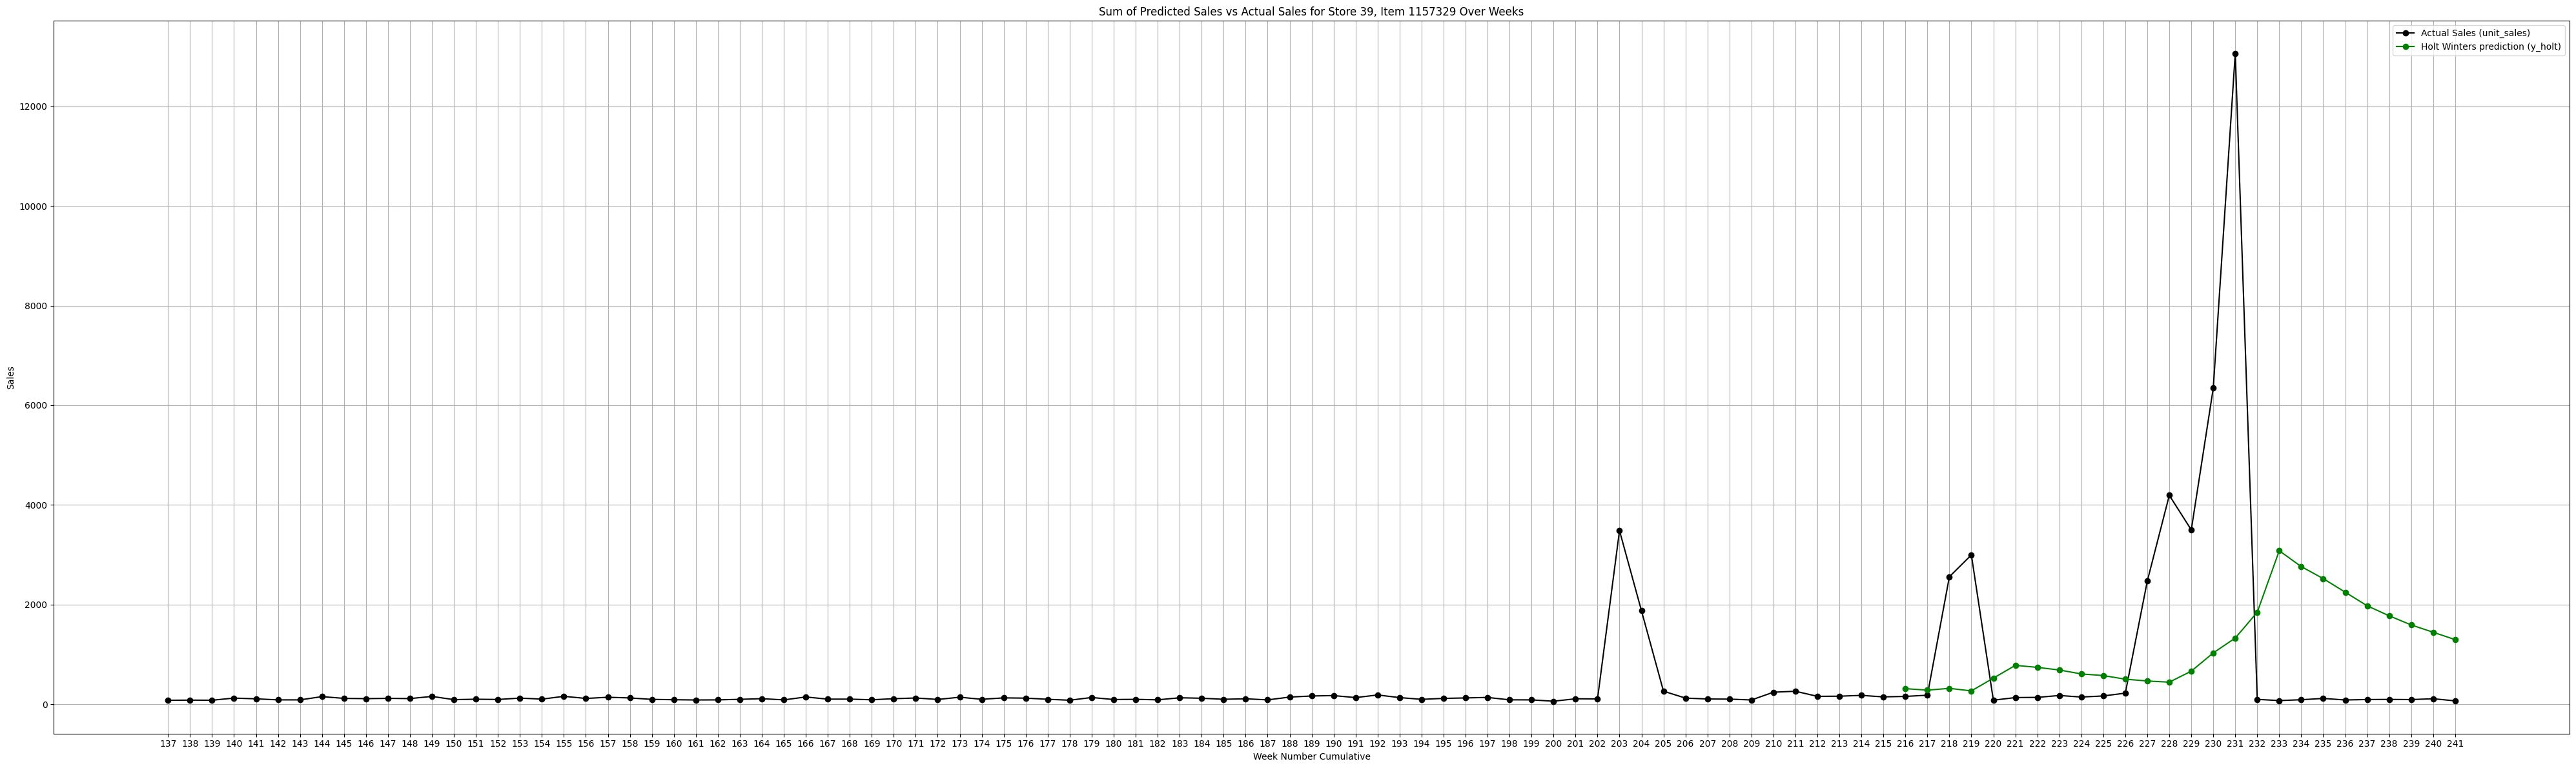

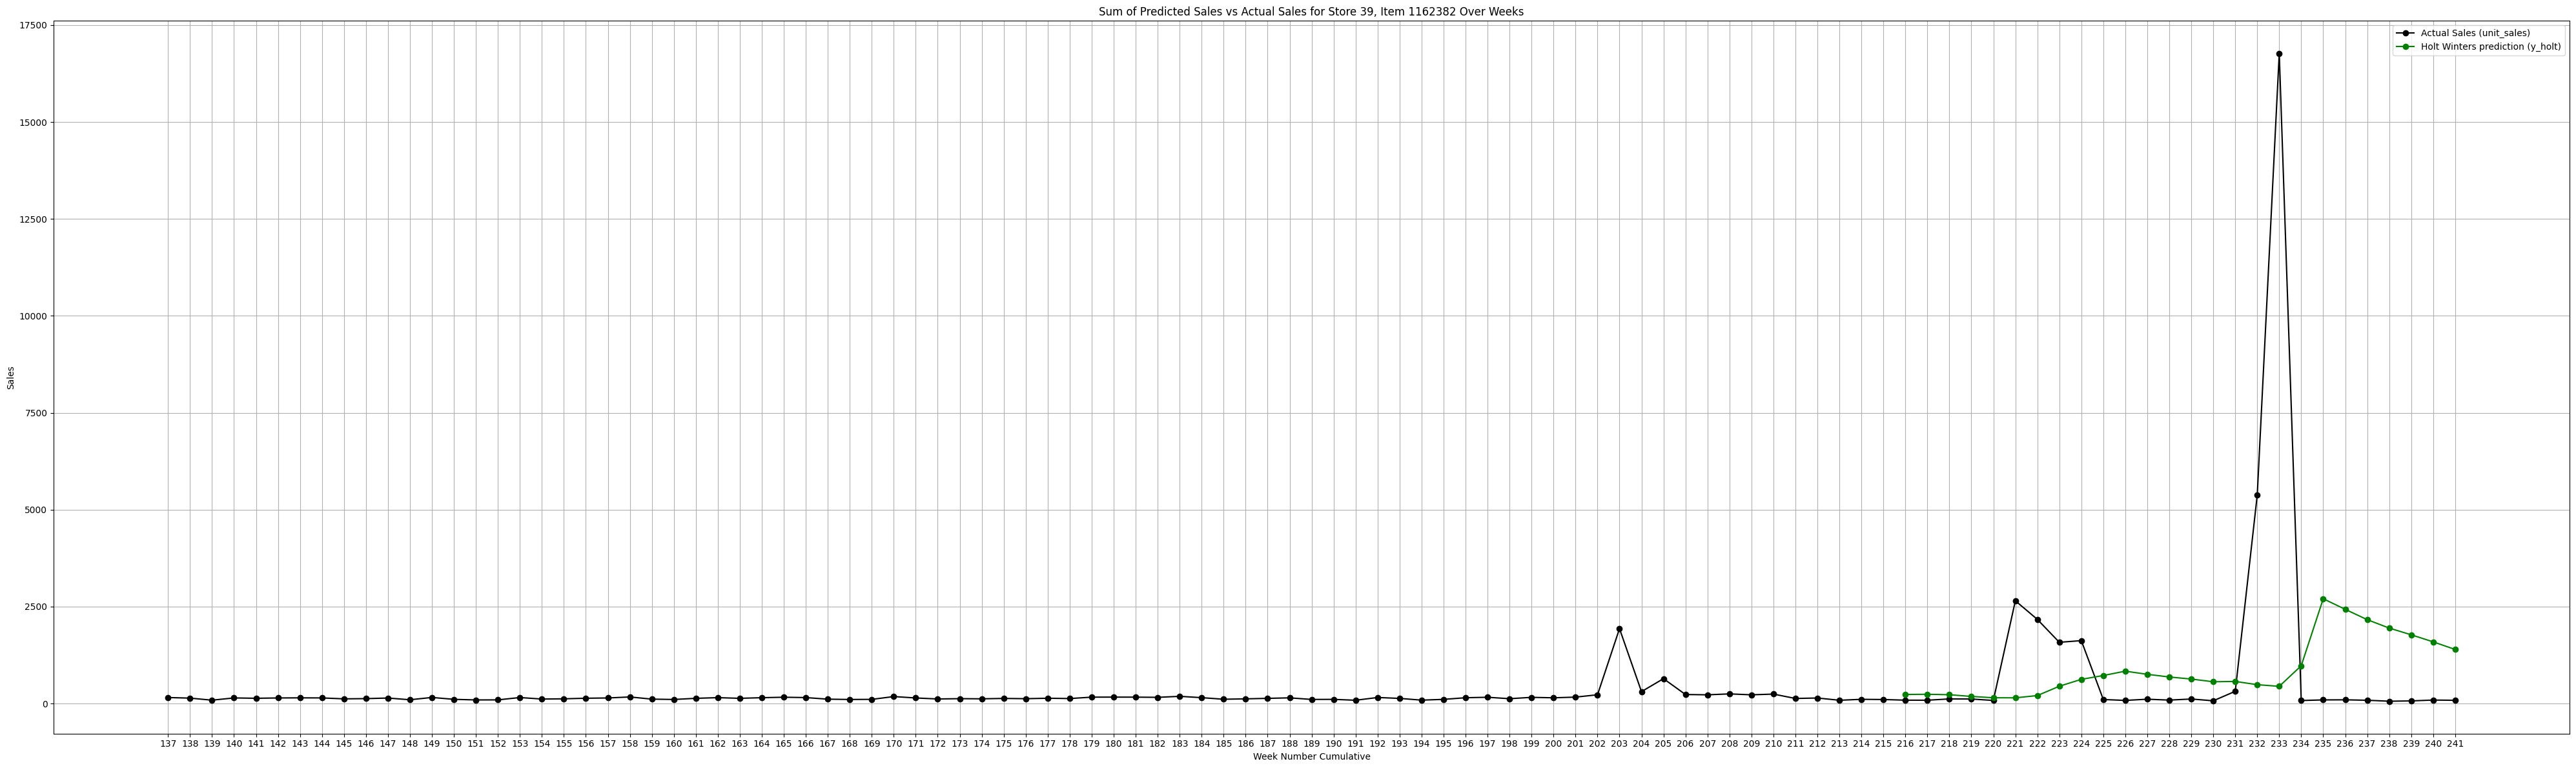

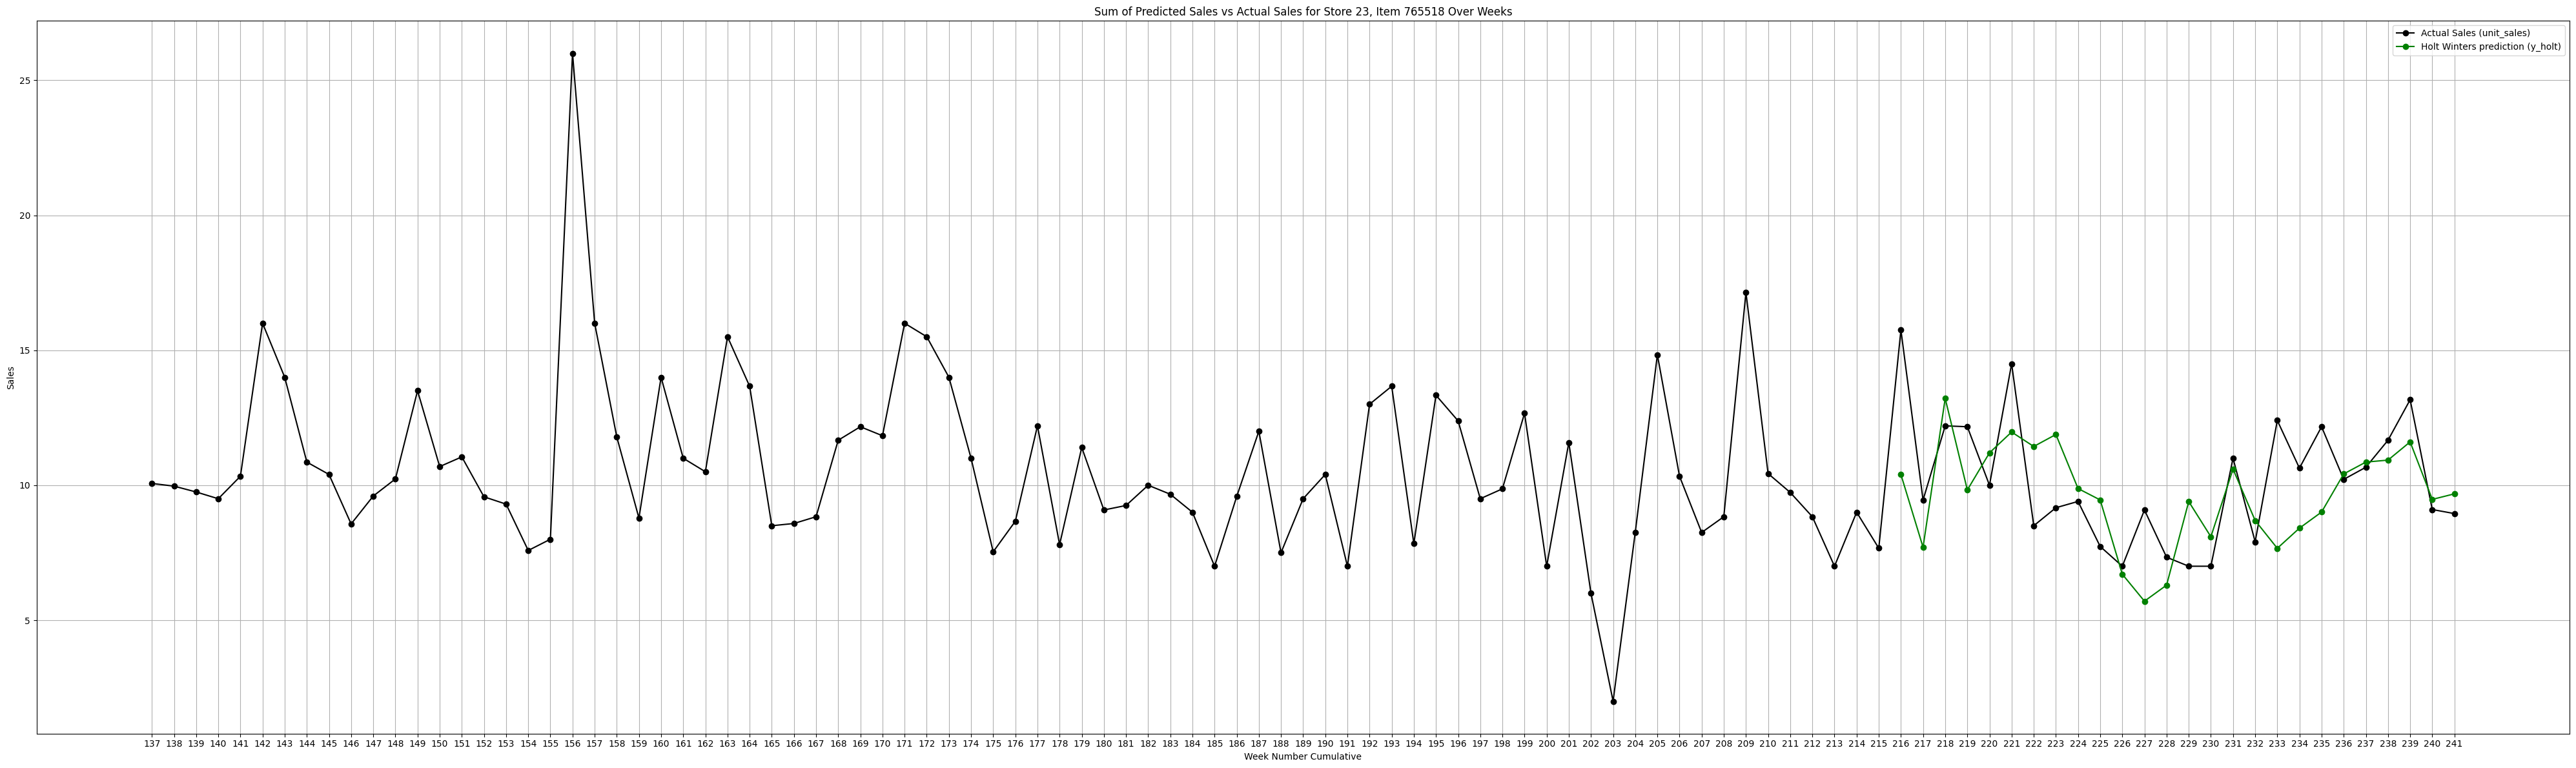

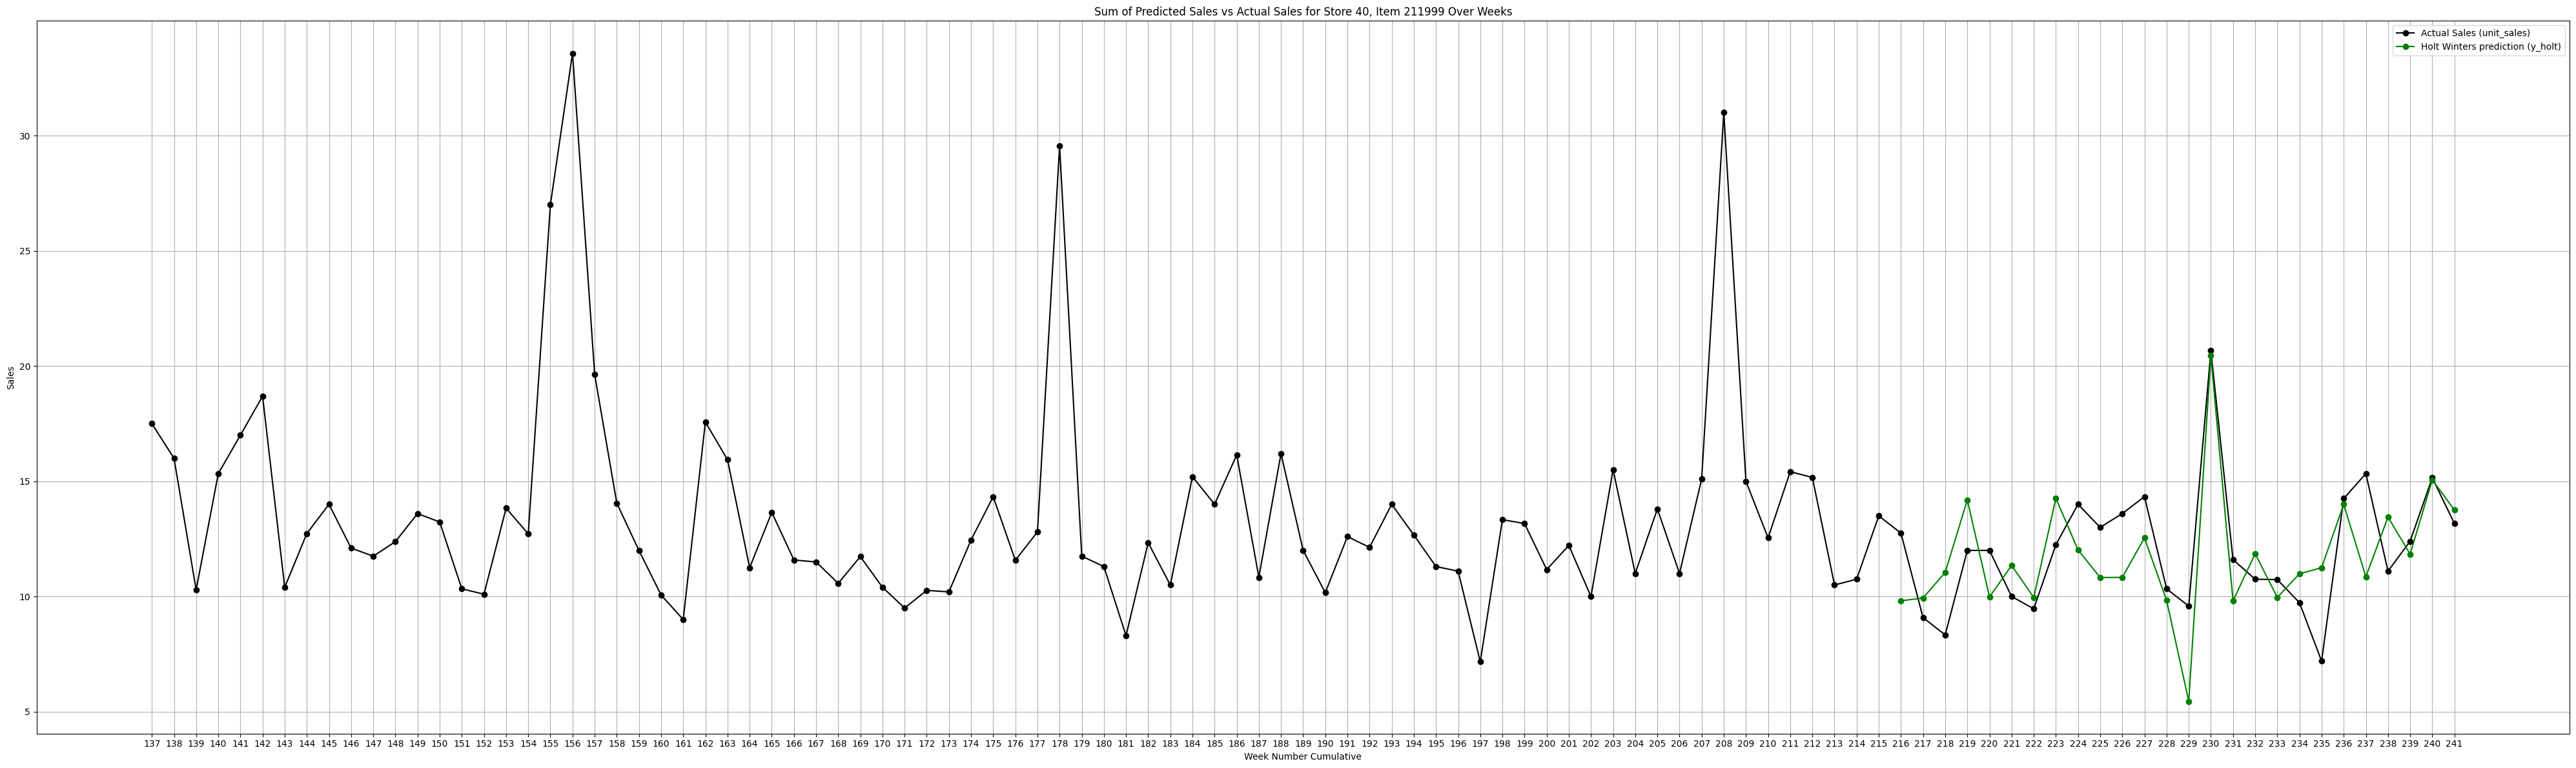

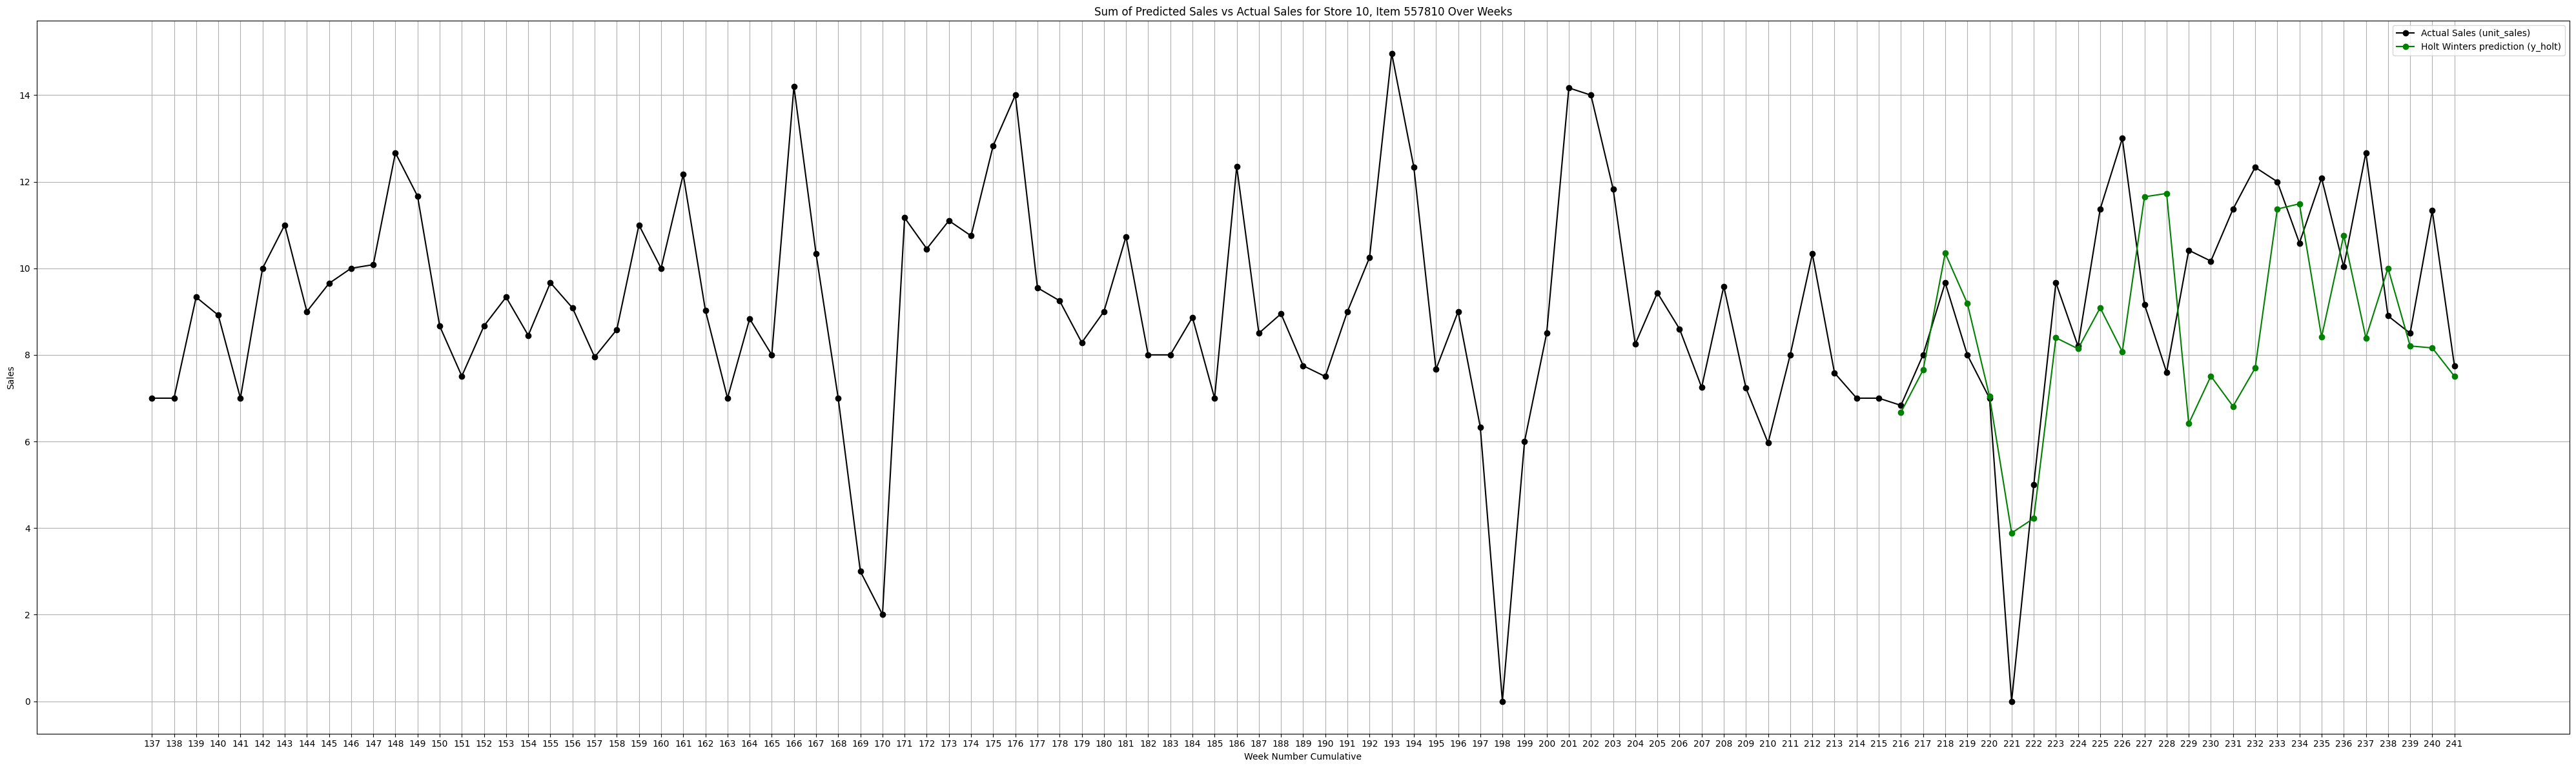

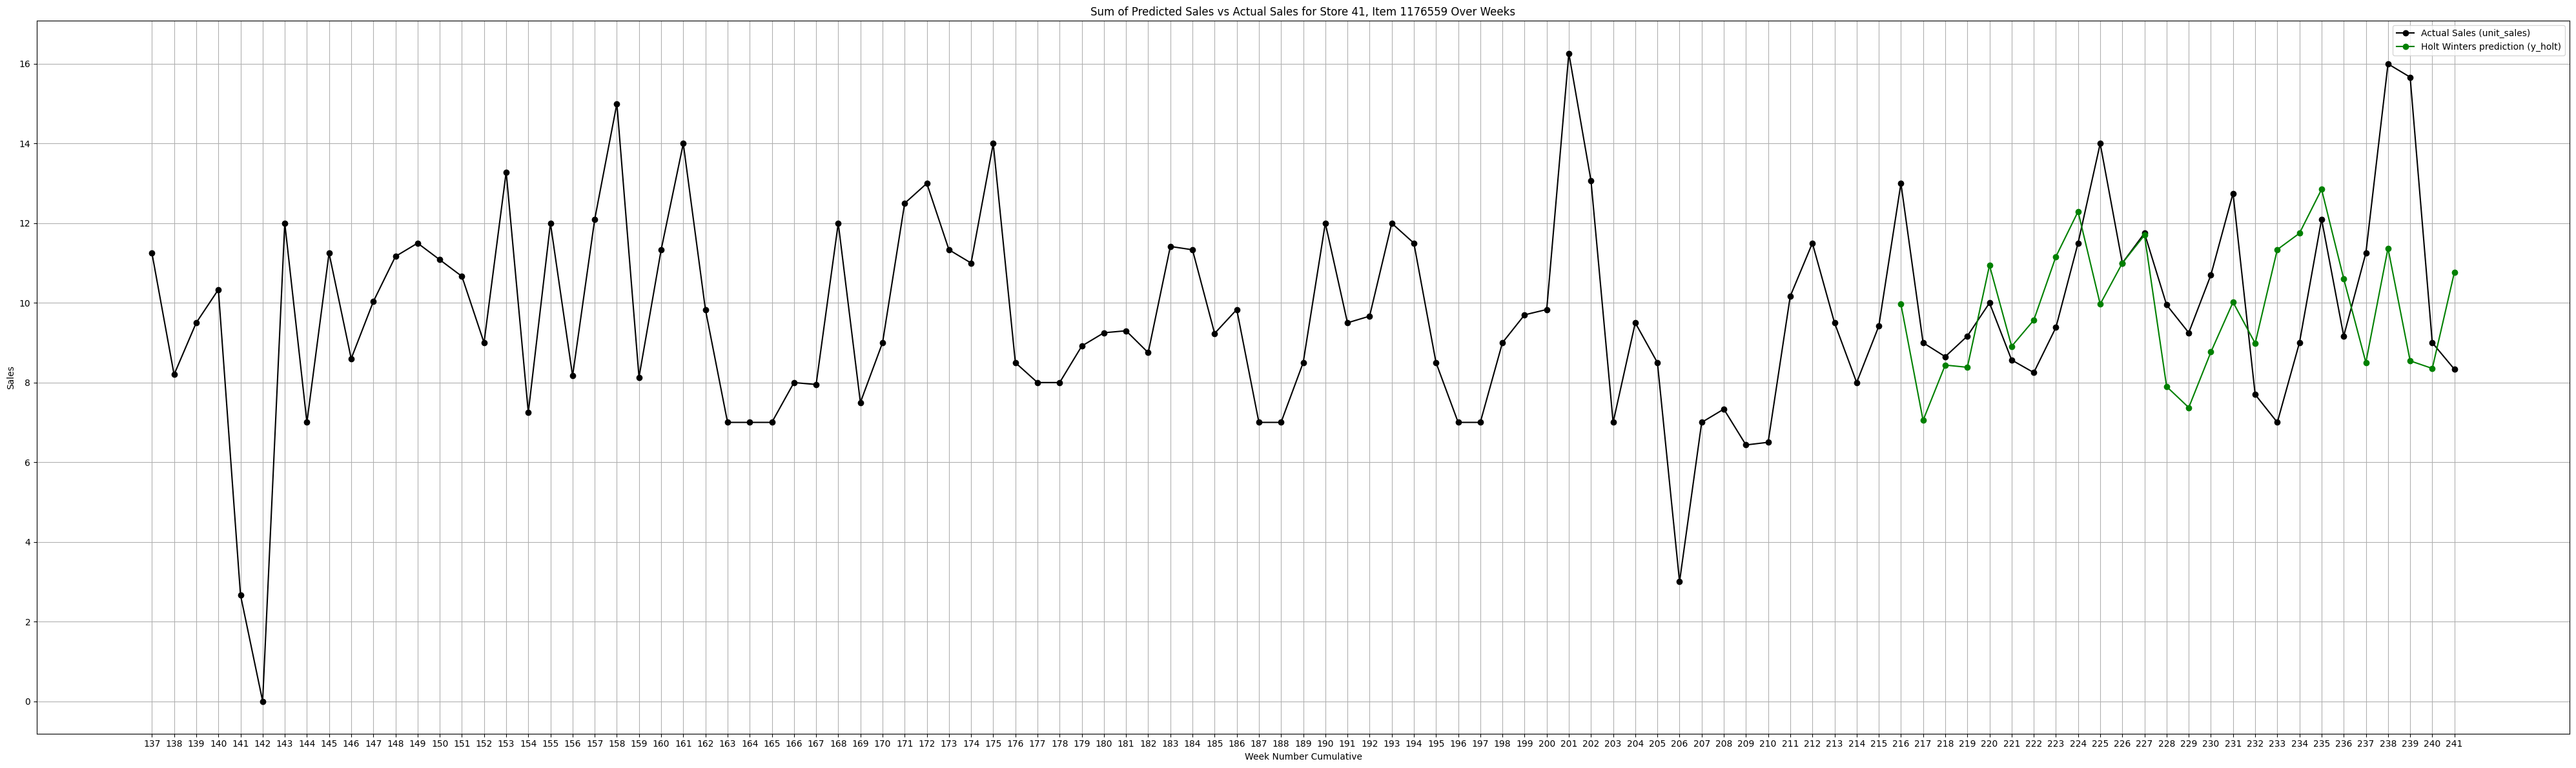

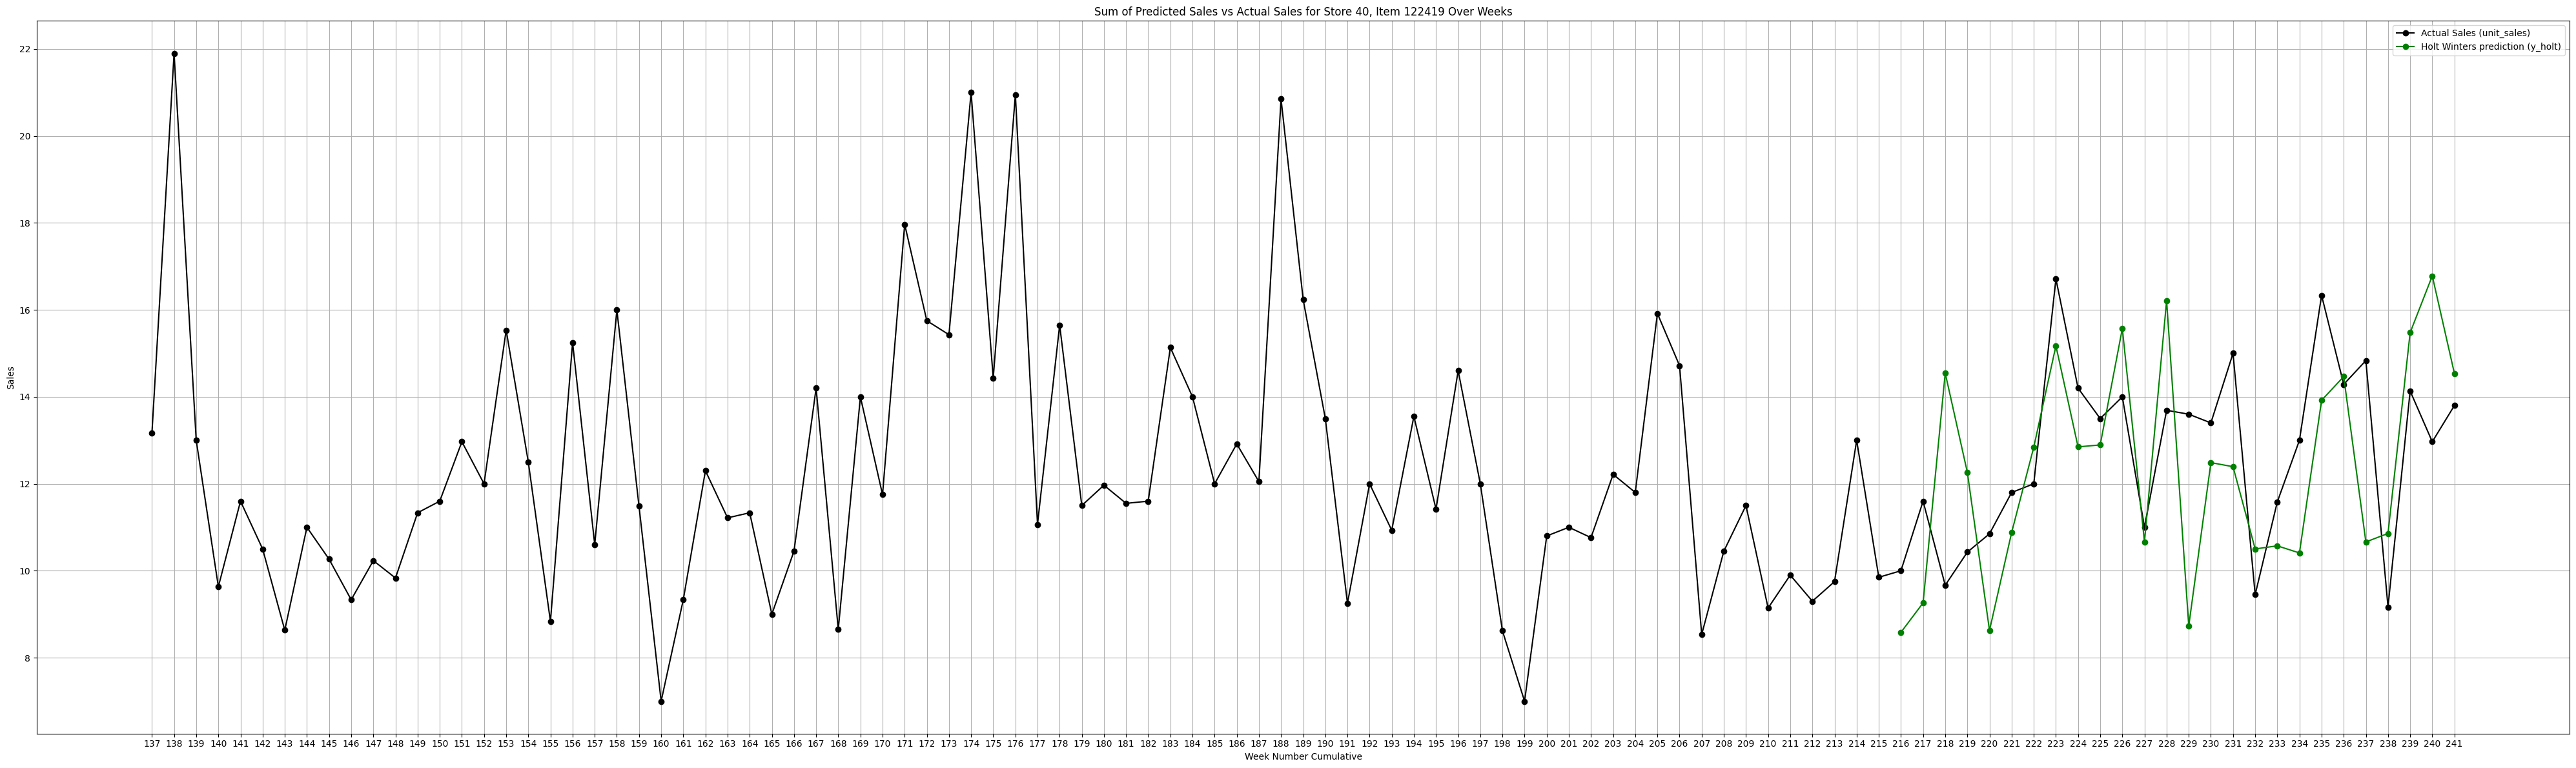

In [260]:
# List of top 5 maximum and top 5 minimum combinations from your output
# Least performers 
top_5_max_combinations = [
    (46, 1157329), (32, 1157329), (41, 1157329), (39, 1157329), (39, 1162382)
]

# Best performers
top_5_min_combinations = [
    (23, 765518), (40, 211999), (10, 557810), (41, 1176559), (40, 122419)
]

# Combine the lists for all combinations
all_combinations = top_5_max_combinations + top_5_min_combinations

# Loop through each combination of store and item
for store, item in all_combinations:
    # Filter the DataFrame for the specific store/item combination
    grouped_df = df_all[(df_all['store_nbr'] == store) & (df_all['item_nbr'] == item)]
    
    # Group by week_number_cum and sum sales columns
    grouped_df = grouped_df.groupby('week_number_cum')[['y_xgb', 'unit_sales', 'y_naive', 'y_mean', 'y_holt']].sum(min_count=1).reset_index()

    # Step 3: Plot the results
    plt.figure(figsize=(40, 12))
    
    # Plot the Actual Sales
    plt.plot(grouped_df['week_number_cum'], grouped_df['unit_sales'], marker='o', label='Actual Sales (unit_sales)', color='black')
    
    # Plot the Holt Winters prediction
    plt.plot(grouped_df['week_number_cum'], grouped_df['y_holt'], marker='o', label='Holt Winters prediction (y_holt)', color='green')

    # Optionally, you can add other predictions as well
    # plt.plot(grouped_df['week_number_cum'], grouped_df['y_xgb'], marker='o', label='XGB prediction (y_xgb)', color='blue')
    # plt.plot(grouped_df['week_number_cum'], grouped_df['y_naive'], marker='o', label='Naive prediction (y_naive)', color='red')
    # plt.plot(grouped_df['week_number_cum'], grouped_df['y_mean'], marker='o', label='Average mean prediction (y_mean)', color='orange')

    # Add titles and labels
    plt.title(f'Sum of Predicted Sales vs Actual Sales for Store {store}, Item {item} Over Weeks')
    plt.xlabel('Week Number Cumulative')
    plt.ylabel('Sales')
    plt.xticks(grouped_df['week_number_cum'])  # Set x-ticks to show all weeks
    plt.legend()
    plt.grid()  # Remove grid as per the previous request

    # Show the plot
    plt.tight_layout()
    plt.show()
